In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [70]:
df = pd.read_csv('./content/data/train.csv')
print(f'Shape is {df.shape}')
df.head(10)

Shape is (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


Вообще, следовало бы почитать самый популярныцй EDA ноутбук на Каггл и от него уже отталкиваться в анализе данных.\
Но интересно попробовать провести собственный анализ без использование чужих решений.

У нас здесь 80 фичей. Надо каждую (или почти каждую) проверить как она влияет на таргет. Проверить есть ли корреляция между фичами.\
Не забыть заполнить null-значения.

Стоит заметить, что почти все фичи у нас категориальный. Это значит, каждую из них надо преобразовывать для обучения моделей.\
Стоит вопрос, как именно их обрабатывать: с помощь *One-hot-encoding* или *Ordinal-encoding*.\
По предыдущему проекту могу сказать, что модели лучше обучаются на *One-hot-encoding*, но при этом таблица очень хорошо разрастается.\
У нас здесь 80 фичей, почти все категориальные, каждый из которых имеет несколько значений. Если применить *One-hot-encoding*, таблица может вырасти до 200-300 фичей.\
В процессе анализа стоит попробовать найти порядок у категориальных фичей и при фича-инженеринге применять *Ordinal-encoding*.

В таблице присутствуют null-значения. Это не баг, так и должно быть, но графики отказыают отображать null-значения.\
Поэтому далее все null-значения, где это необходимо, преобразовываются в значение *Absent*.

# Проверка null-значений

In [71]:
null_count = df.isnull().sum()
null_count[df.isnull().sum() > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

19 фичей из 80 имеют null-значения. Большинство null-значений содержится в *Alley*, *MasVnrType*, *FireplaceQu*, *PoolQC*, *Fence*, *MiscFeature*.

**Alley** — данная фича указывает тип аллеи у дома. Большое количество null-значений показывает, что дома не имеют аллеи.\
У тех домов, где аллея есть, значений может быть *Paved \[Pave]* или *Gravel \[Grvl]*:
- *Paved* означает твёрдное покрытые (асфальт, бетон, каменные плиты);
- *Gravel* означает гравийное покрытие (щебень, галька, отсев).

Тип поктыия *Paved* явно лучше *Gravel*, поэтому фичу **Alley** можно расположить в порядке:\
*None* < *Gravel* < *Paved*.

**MasVnrType** — облицовка стен дома из кирпичной кладки. Защищает дом от дождя, ветра и холода, а также делает фасад красивым и аккуратным.\
Null-значения означают, что облицовки нет. Дома с облицовкой имеются значения *Brick Common \[BrkCmn]*, *Brick Face \[BrkFace]*, *Cinder Block \[CBlock]* и *Stone*.
- *Brick Common* — облицовка, не предназначенная для декора, применяется для внутренних или черновых стен;
- *Brick Face* — предназначен для видимого, привлекательного и долговечного внешнего слоя здания;
- *Cinder Block* — облицовка из шлакоблоков;
- *Stone* — каменная облицовка.

Фичу **MasVnrType** можно раположить в следующем порядке:\
*None* < *Cinder Block* < *Brick Common* < *Brick Face* < *Stone*.

**FireplaceQu** — качество камина. Большинство null-значений показывает, что камины просто отсутствуют.\
Порядок очевидный:\
*None* < *Poor* < *Fair* < *Average* < *Good* < *Excellent*.

**PoolQC** — качество бассейна. Большинство null-значений показывает, что бассейны просто отсутствуют.\
Порядок очевидный:\
*None* < *Fair* < *Average*/*Typical* < *Good* < *Excellent*.

**Fence** — качество забора. Измеряется в конфиденциальности, простыми словами как хорошо прохожим видно происходящее во дворе.\
Очевидный порядок:\
*No Fence* < *Minimum Wood/Wire* < *Good Wood* < *Minimum Privacy* < *Good Privacy*.

**MiscFeature** — дополнительные признаки, не рассмотренные в других категориях. Имеет следующие значения:
- *Elevator* — лифт;
- *2nd Garage* — второй гараж;
- *Other* — другое;
- *Shed* —  сарай (больше 100кв.футов);
- *None* — ничего.

Понятно, что в **MiscFeature** null-значения показывает, что дополнительных ценностей у дома нет. Если они есть, они указаны в данной фиче + признак *MiscValue* указывает ценность.\
Можно было бы попробовать преобразовать данную фичу в ориднальную, но думаю, лучше всего её будет обработать с помощью *One-hot-encoding*.\
Причём в обычном *One-hot-encoding* стоят значения 1 и 0, в зависимости от наличие или отсутствия признака. Но здесь у нас в столбце *MiscValue*\
сразу указана ценность предмета, так что можно использовать *One-hot-encoding* и сразу вместо 1 ставить стоимость предмета.

---

Есть ещё много фич с null-значения, подробно их разбирать щас не буду. Но при фича-инженеринге их тоже надо будет постараться заполнить какими-то значениями.

# Анализ фичей

## MSSubClass
Тип жилья, выставленного на продажу.\
Имеет следующие значения:
- 20  — 1-STORY 1946 & NEWER ALL STYLES
- 30  — 1-STORY 1945 & OLDER
- 40  — 1-STORY W/FINISHED ATTIC ALL AGES
- 45  — 1-1/2 STORY - UNFINISHED ALL AGES
- 50  — 1-1/2 STORY FINISHED ALL AGES
- 60  — 2-STORY 1946 & NEWER
- 70  — 2-STORY 1945 & OLDER
- 75  — 2-1/2 STORY ALL AGES
- 80  — SPLIT OR MULTI-LEVEL
- 85  — SPLIT FOYER
- 90  — DUPLEX - ALL STYLES AND AGES
- 120 — 1-STORY PUD (Planned Unit Development) - 1946 & NEWER
- 150 — 1-1/2 STORY PUD - ALL AGES
- 160 — 2-STORY PUD - 1946 & NEWER
- 180 — PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
- 190 — 2 FAMILY CONVERSION - ALL STYLES AND AGES

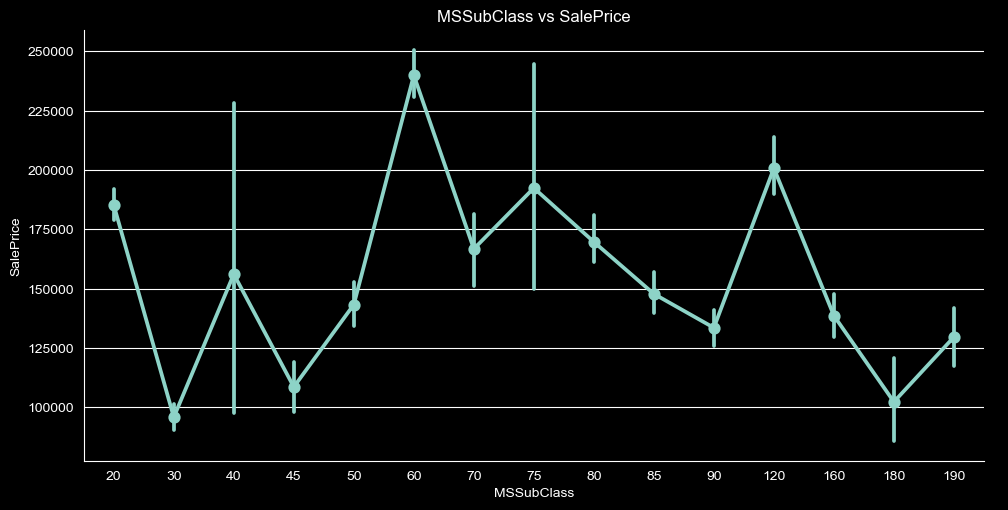

In [72]:
sns.catplot(data=df,
            x='MSSubClass',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)

plt.title('MSSubClass vs SalePrice')
plt.show()

Самыми дорогими на рынке явлются 2-этажные дома 1946 года и новее. За ними идут 1-этажные ПУДы 1946 года и новее.

1-этажные дома с обустроенным чердаком (MSSubClass = 40) имеют очень большой разброс. Видимо, там очень много шумных объектов.\
Аналогичная ситуация и с 2.5-этажными домами всех возрастов (MSSubClass = 75).

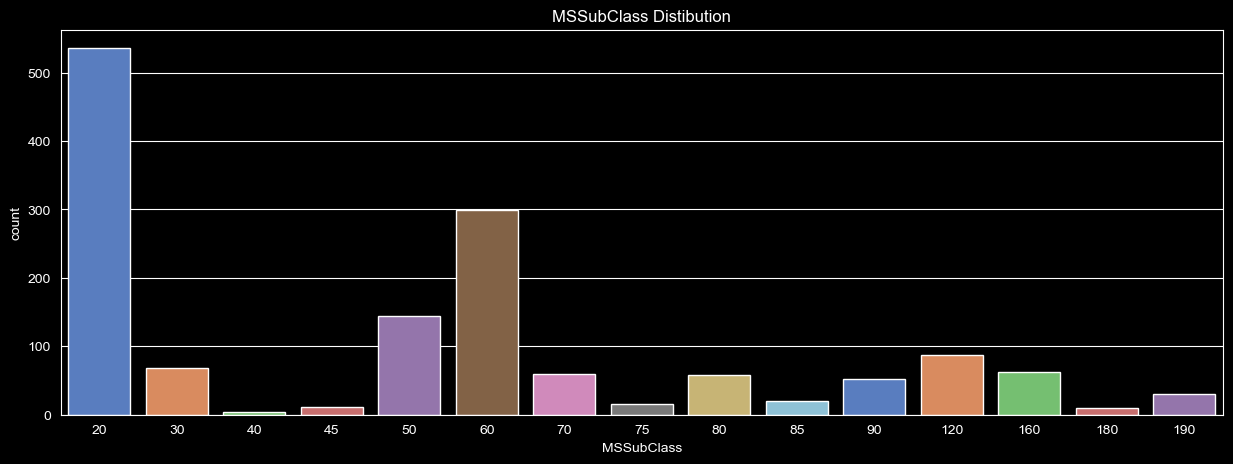

In [73]:
plt.figure(figsize = (15,5))
sns.countplot(data=df, x='MSSubClass', palette='muted')
plt.title('MSSubClass Distibution')
plt.show()

In [74]:
df[df['MSSubClass'] == 40]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
164,165,40,RM,40.0,5400,Pave,Pave,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2007,WD,Normal,152000
589,590,40,RM,50.0,9100,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,600,8,2008,WD,Normal,79500
873,874,40,RL,60.0,12144,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Othr,0,9,2009,WD,Normal,133000
1270,1271,40,RL,NaN,23595,Pave,NaN,Reg,Low,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,260000


Интересная ситуация с домами "1-STORY W/FINISHED ATTIC ALL AGES". У нас в датасете 1460 сэмплов, но всего 4 из них являются "1-STORY W/FINISHED ATTIC ALL AGES".\
С таким количеством тяжело сделать объективно предположение. К тому же, у одного из них очень низкая цена продажи: 79.5k\\$, тогда как у остальных 133k\\$+.\
Хотя если посмотреть на его признаки, он не сильно отличается от остальных:
- Местоположение *Condition1* = RRAn, в то время как остальных *Condition1* = Norm;
- Местоположение *Condition2* = Feedr, в то время как остальных *Condition2* = Norm;
- Подвал 1 *BsmtFintype1* = Unf, т.е. подвал не завершён в отличие от остальных (из-за чего *BsmtFinSF1* = 0);
- Площадь первого этажа *1stFlrSF* = 779, что заметно ниже по сравнению с другими (1036+);
- Площадь жилого помещения *GrLivArea* = 935, в то время как у остальных 1268+;
- Дополнительно имеет сарай ценность 600 *MiscFeature* = Shed & *MiscVal* = 600, когда у остальных вообще ничего нет.

Возможно, расположение дома, незаконченный подвал общая площадь жилого помещения повлияла на ценность дома.
Хотя разница в значениях небольшая, чтобы стоимость так отличалась.

Ещё интересное наблюдение: дом выставлен на продажу в 2008 году, тогда как остальные выставлены на продажу в 2007, 2009 и 2010.
И именно в 2008 году был ипотечный кризис в США. Хотя условия сделки указаны Normal, что говорит об обычной продажи данного дома.\
Предположу, что дом не был изъят банком за долги, но владелец сам выставил его за низкую стоимость, чтобы не попасть в критическую ситуацию, отчего такая и низкая цена.\
Возможно от данного сэмпла надо будет избавить, идентифицируя его как шумовой объект.

In [75]:
df[df['MSSubClass'] == 75]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
61,62,75,RM,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Normal,101000
185,186,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000
197,198,75,RL,174.0,25419,Pave,NaN,Reg,Lvl,AllPub,...,512,Ex,GdPrv,NaN,0,3,2006,WD,Abnorml,235000
198,199,75,RM,92.0,5520,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2009,WD,Abnorml,104000
267,268,75,RL,60.0,8400,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,179500
304,305,75,RM,87.0,18386,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,295000
328,329,75,RL,NaN,11888,Pave,Pave,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,214500
583,584,75,RM,75.0,13500,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,325000
735,736,75,RM,60.0,10800,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2006,WD,Normal,163000
784,785,75,RM,35.0,6300,Pave,Grvl,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,128000


У домов "2-1/2 STORY ALL AGES" в принципе большой разброс. Больше всего выделился дом с *Id* = 186, его стоимость составляет почти 500k\\$, тогда как у остальных средняя цена < 200k\\$.
Если посмотреть на его значения, видно, что дом находится в прекрасном состоянии и имеет большую площодь. Построен 19-м веке и реконструирован в конце 20-го века.
Преположу, что данный объект хоть и отличается сильно от остальных, не является шумовым.

## MSZoning
Показывает градостроительное назначение земли:
- A — Agriculture (сельское хозяйство)
- C — Commercial (коммереция)
- FV — Floating Village Residential (элитные здания у воды)
- I — Industrial (заводы, фабрики, склады)
- RH — Residential High Density (многоэтажки)
- RL — Residential Low Density (частные дома)
- RP — Residential Low Density Park (частные дома у парков)
- RM — Residential Medium Density (таунхаусы)

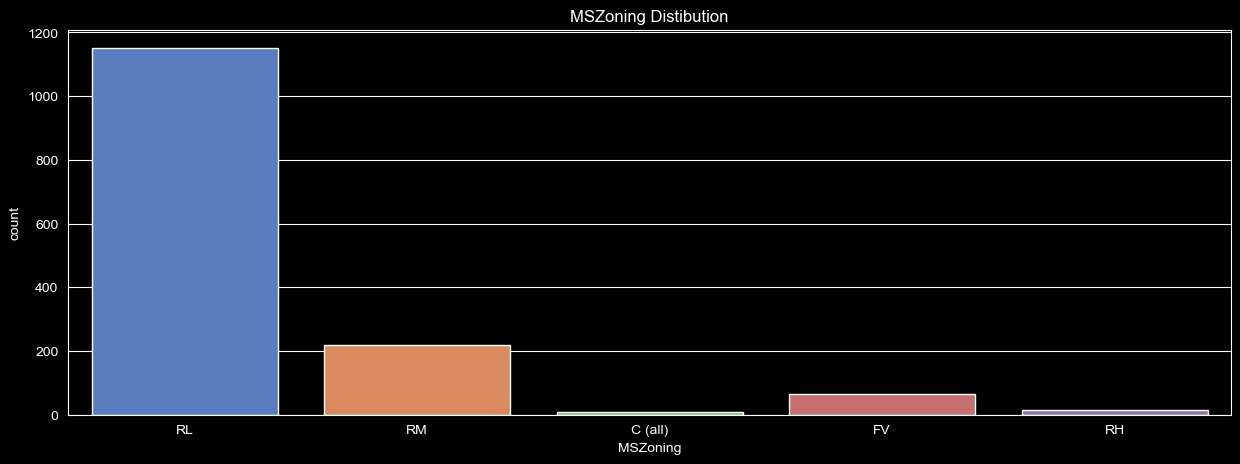

In [76]:
plt.figure(figsize = (15,5))
sns.countplot(data=df, x='MSZoning', palette='muted')
plt.title('MSZoning Distibution')
plt.show()

В датасете присутствуют только частные дома, таунхаусы, коммерческие здания, элитные здания у воды и многоэтажки.\
Хотя возможных значений 8, т.е. 3 значения не нужны и для них модель никак не обучится. Возможно стоит их удалить или заменить на *Other*.

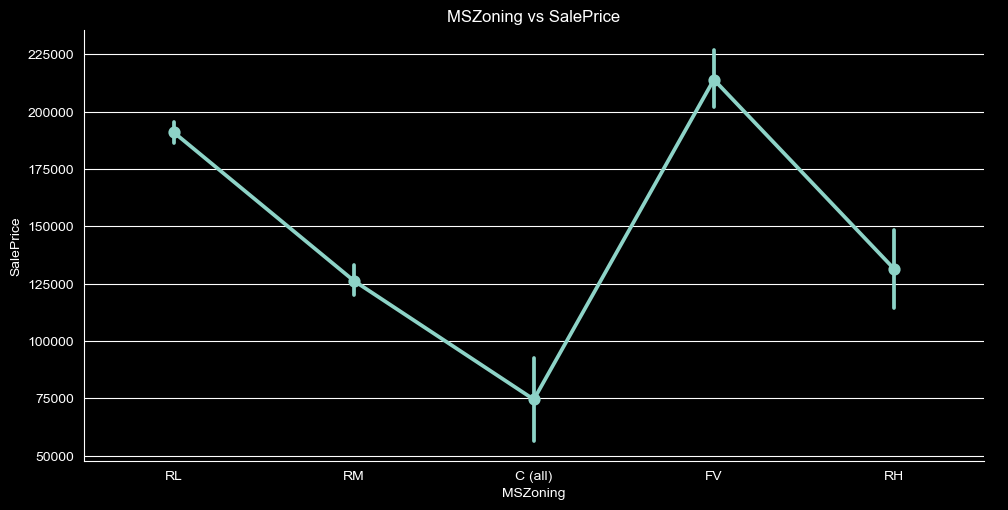

In [77]:
sns.catplot(data=df,
            x='MSZoning',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)

plt.title('MSZoning vs SalePrice')
plt.show()

Логично, что элитные здания у воды стоят больше всего.\
Коммерческие стоят меньше всего и имеют большое отклонение. Думаю, это связано с низкой ликвидностью коммерческих задний.

Интересное наблюдение: таунхаусы (RM) стоят чуть нижен многоэтажен (RH), хотя жить в таунхасе комфортнее, т.к. там меньше соседей и спокойнее.

## LotFrontage
Показывает ширину участка, который выходит прям на улицу/дорогу, в футах (1 фут = 0.3 метра).

Посмотрим максимальное, минимальное и среднее значение:

In [78]:
print(f'Max is {df['LotFrontage'].max()} \nMin is {df['LotFrontage'].min()} \nAvg is {df['LotFrontage'].mean()}')

Max is 313.0 
Min is 21.0 
Avg is 70.04995836802665


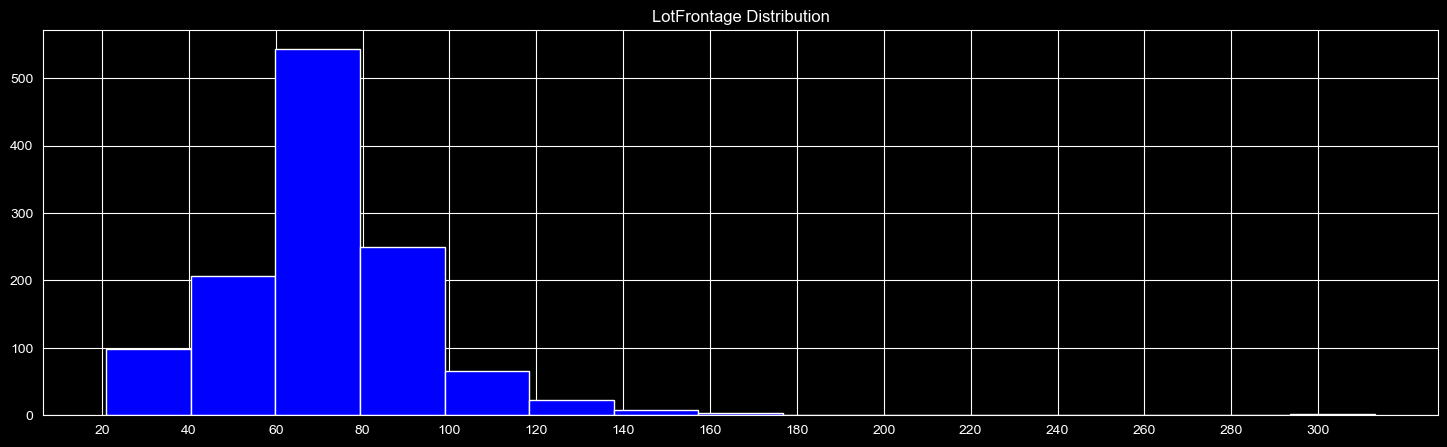

In [79]:
plt.figure(figsize = (18,5))
plt.hist(df['LotFrontage'], bins=15, color='blue')

plt.title('LotFrontage Distribution')
plt.xticks(range(20, 315, 20))
plt.show()

Ширина участка у улице вартируется от 20 до 180 футов, также есть участок шириной около 300 футов. Проверим, есть ли участки шириной от 180 до 300 футов:

In [80]:
df[(df['LotFrontage'] > 180) & (df['LotFrontage'] < 300)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1127,1128,20,RL,182.0,14572,Pave,NaN,IR3,Lvl,AllPub,...,0,NaN,NaN,NaN,0,11,2007,WD,Family,259000


Всего-лишь один участок с шириной 182 фута. При разбиении непрервной величины в дискретную можно будет не создавать для него отдельную группу.

Проверим, сколько домой с шириной больше 300 футов:

In [81]:
df[df['LotFrontage'] > 300]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
934,935,20,RL,313.0,27650,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,11,2008,WD,Normal,242000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


Всего-лишь 2 и оба шириной 313.

Непрерывную величину *LotFrontage* можно разбить на дискретную по следующим отрезкам: \[20, 40, 60, 80, 100, 120, 140, 160, 185, np.inf]:

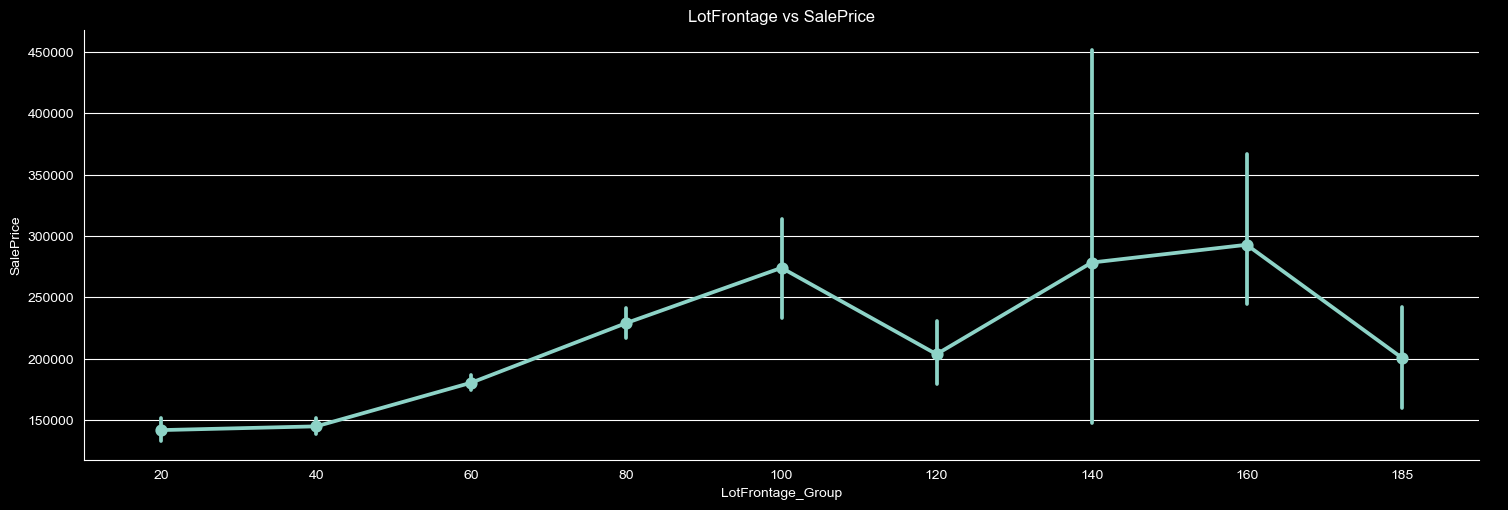

In [82]:
df['LotFrontage_Group'] = pd.cut(x=df['LotFrontage'],
                                 bins=[20, 40, 60, 80, 100, 120, 140, 160, 185, np.inf],
                                 labels=[20, 40, 60, 80, 100, 120, 140, 160, 185],
                                 include_lowest=True)

sns.catplot(data=df,
            x='LotFrontage_Group',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=3)
plt.title('LotFrontage vs SalePrice')
plt.show()

Логично предположить, что с ростом ширины участка у дороги стоимость должна расти.\
Так и происходит, для домой с шириной 185+ футов цена резко падает. Такая же ситуация с домами шириной 120-140 футов.

Думаю, ширина лицевой стороны участка не такой важный признак, чтобы подозревать сэмплы шумовыми.

## LotArea
Показывает размер участка в квадратных футах (1 фут = 0.3 метра).

Посмотрим максимальное, минимальное и средние значения:

In [83]:
print(f'Max is {df['LotArea'].max()} \nMin is {df['LotArea'].min()} \nAvg is {df['LotArea'].mean()}')

Max is 215245 
Min is 1300 
Avg is 10516.828082191782


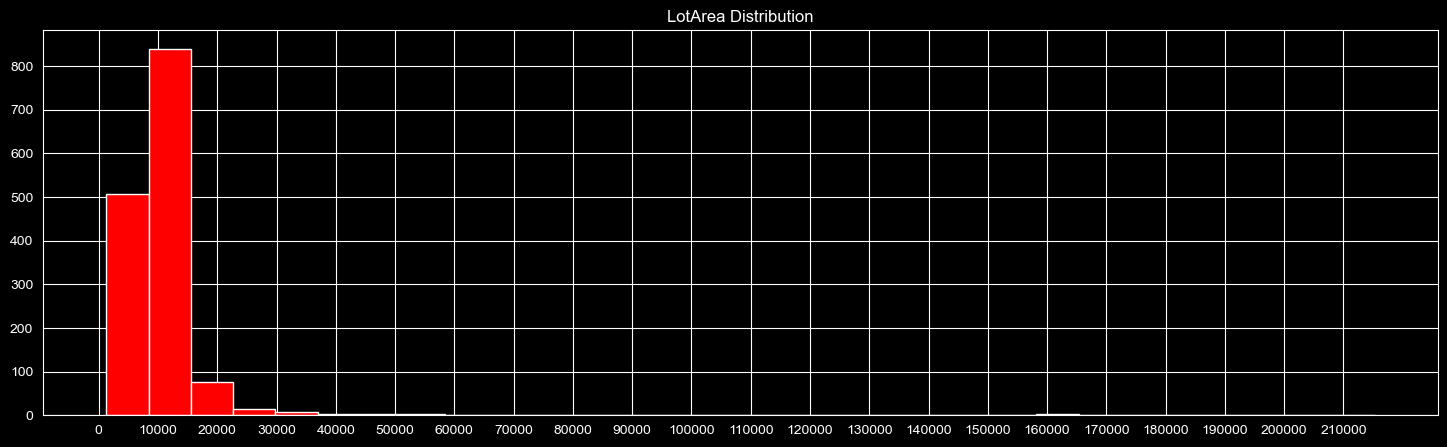

In [84]:
plt.figure(figsize = (18,5))
plt.hist(x=df['LotArea'],
         bins=30,
         color='red')
plt.title('LotArea Distribution')
plt.xticks(range(0, 216_000, 10_000))
plt.show()

Можно сказать, все дома имеют размер участка от 1 300 до 40 000 футов. После 40 000 количество домой очень-очень мало:

In [85]:
df[df['LotArea'] > 40_000].shape[0]

14

Следовательно, все дома с площадью участка > 40 000 футов можно поместить в один бин.

Но глянем точнее на дома с участком до 40 000 футов:

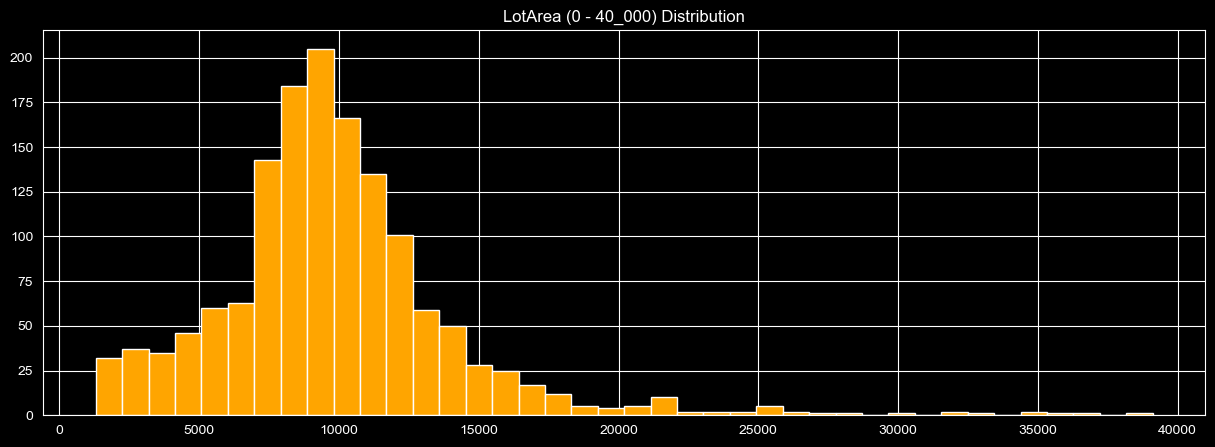

In [86]:
plt.figure(figsize = (15,5))
plt.hist(x=df[df['LotArea'] < 40_000]['LotArea'],
         bins=40,
         color='orange')
plt.title('LotArea (0 - 40_000) Distribution')
plt.show()

Видим, большинство домой имеют участок около 10 000 футов, примерно 80% домов имеют участник от 5 000 до 15 000 футов.

Следовательно, бины можно задать следующем образом: \[0, 5 000, 10 000, 15 000, 20 000, 25 000, 30 000, 40 000, np.inf]]

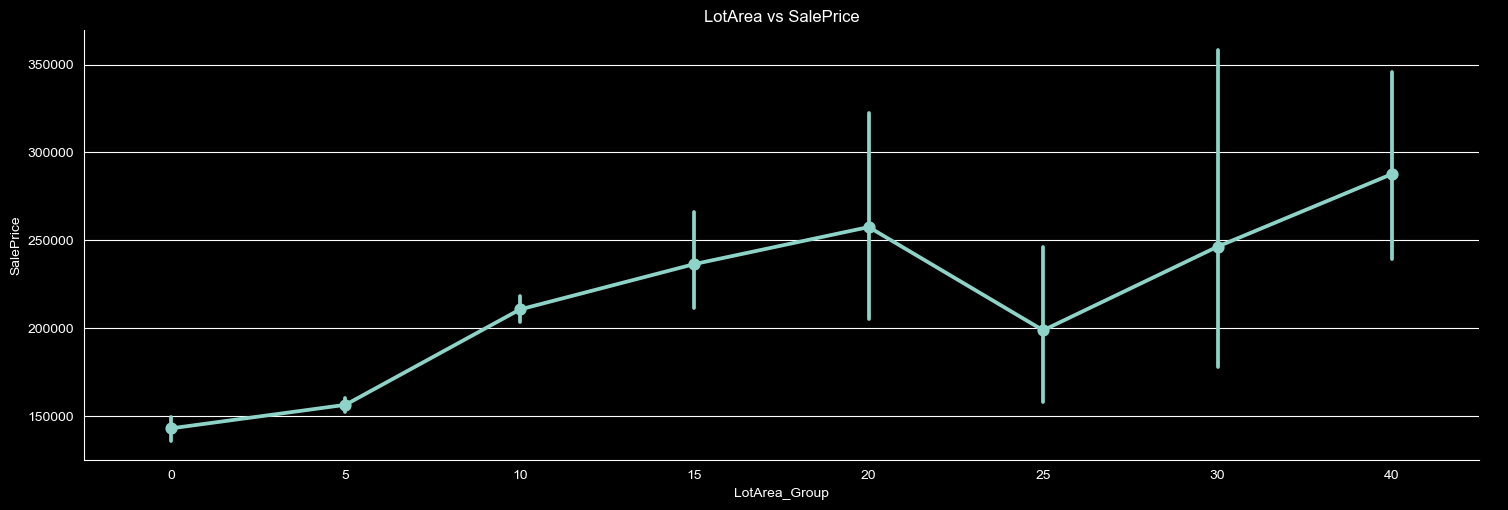

In [87]:
df['LotArea_Group'] = pd.cut(x=df['LotArea'],
                             bins=[0, 5_000, 10_000, 15_000, 20_000, 25_000, 30_000, 40_000, np.inf],
                             labels=[0, 5, 10, 15, 20, 25, 30, 40])

sns.catplot(data=df,
            x='LotArea_Group',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=3)
plt.title('LotArea vs SalePrice')
plt.show()

Как и следовало ожидать, цена растёт с возрастанием площади участка. Хотя и имеет резкое падение на домах участком от 25 000 до 30 000 футов:

In [88]:
df[(df['LotArea'] > 25_000) & (df['LotArea'] < 30_000)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LotFrontage_Group,LotArea_Group
197,198,75,RL,174.0,25419,Pave,NaN,Reg,Lvl,AllPub,...,GdPrv,NaN,0,3,2006,WD,Abnorml,235000,160,25
588,589,20,RL,65.0,25095,Pave,NaN,IR1,Low,AllPub,...,NaN,NaN,0,6,2009,WD,Partial,143000,60,25
692,693,60,RL,42.0,26178,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,0,4,2006,WD,Normal,335000,40,25
828,829,60,RL,NaN,28698,Pave,NaN,IR2,Low,AllPub,...,NaN,NaN,0,6,2009,WD,Abnorml,185000,NaN,25
876,877,20,RL,94.0,25286,Pave,NaN,Reg,HLS,AllPub,...,NaN,NaN,0,1,2007,WD,Normal,132250,80,25
934,935,20,RL,313.0,27650,Pave,NaN,IR2,HLS,AllPub,...,NaN,NaN,0,11,2008,WD,Normal,242000,185,25
1057,1058,60,RL,NaN,29959,Pave,NaN,IR2,Lvl,AllPub,...,NaN,NaN,0,1,2009,WD,Normal,248000,NaN,25
1383,1384,30,RL,NaN,25339,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,0,8,2007,WD,Normal,112000,NaN,25
1446,1447,20,RL,NaN,26142,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,0,4,2010,WD,Normal,157900,NaN,25


Видно, что сэмплов мало для объективной оценки стоимости домов с участком от 25 000 до 30 000. Часть из них продаётся не по стандартной сделке. К тому же условия не сказать что хорошие.\
Поэтому логично увидеть такое резкое падение на графике.

## Street
Показывает материал дороги, из которого она сделана. Могут быть значения *Paved* и *Gravel*.

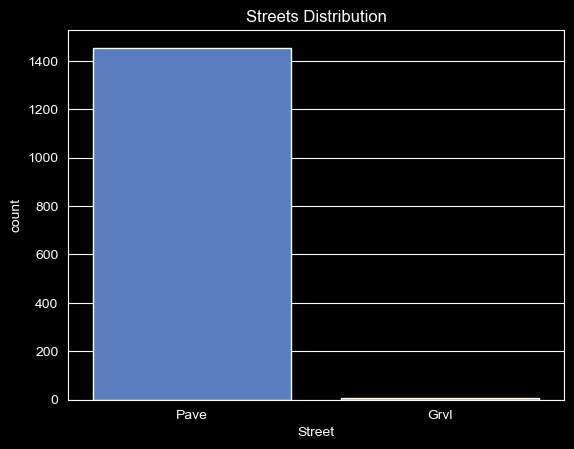

In [89]:
sns.countplot(data=df, x='Street', palette='muted')
plt.title('Streets Distribution')
plt.show()

В основном все дома имеют твёрдое покрытие для подъезда к дому.\
Ничего удивительного график не должен показать: дома с дорогой *Paved* должны стоить дороже.

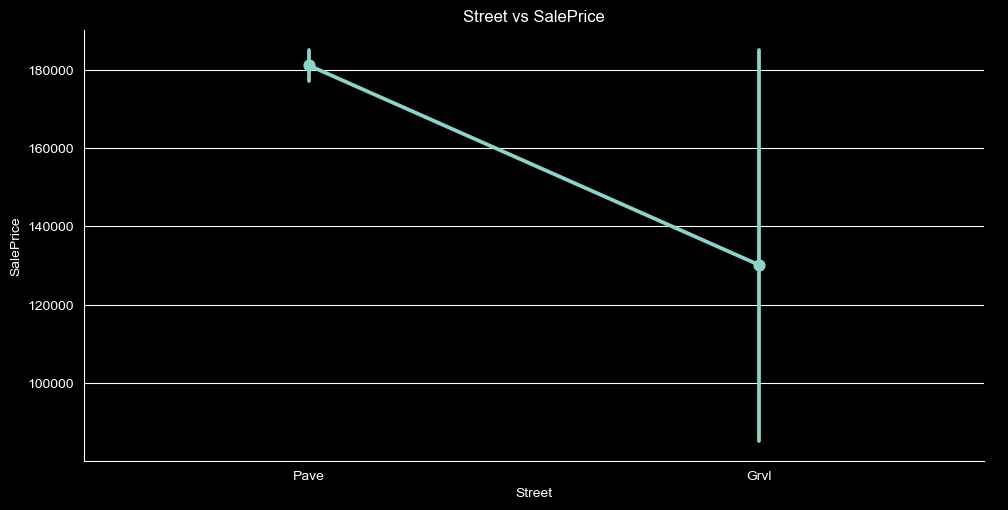

In [90]:
sns.catplot(data=df,
            x='Street',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('Street vs SalePrice')
plt.show()

## Alley
Показывает материал аллеи, из которого она сделана. Могут быть значения *Gravel*, *Paved*, *NA*. Значение *NA* следует заменить для отображения на графиках.

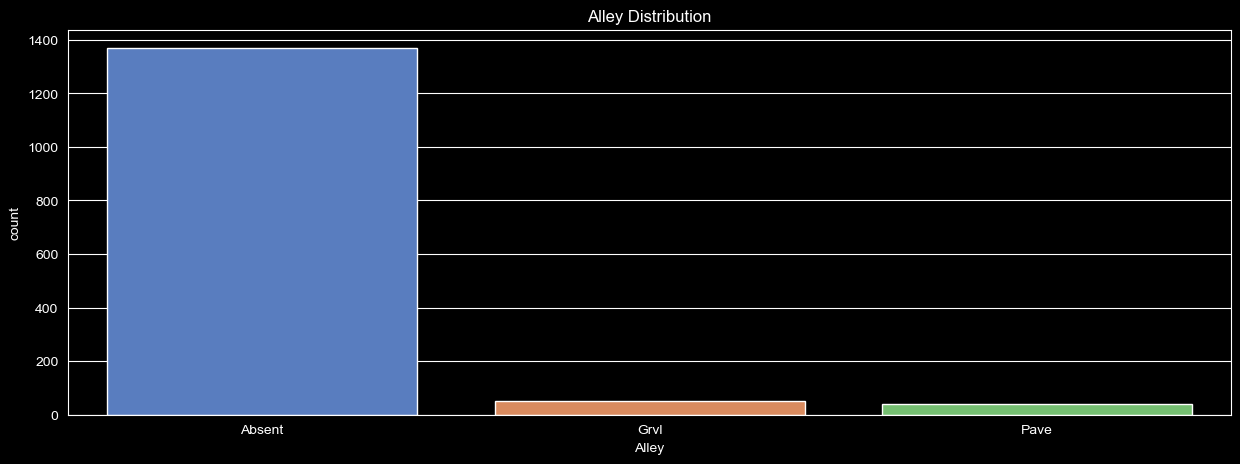

In [91]:
df.loc[df['Alley'].isnull(), 'Alley'] = 'Absent'

plt.figure(figsize = (15,5))
sns.countplot(data=df, x='Alley', palette='muted')
plt.title('Alley Distribution')
plt.show()

Практически во всех домах аллея отсутствует. Логично предположить, что дома без аллеи будут стоить дешевле. Дома с твёрдой аллеей должны стоит дороже, чем с гравием.

Однако стоимость дома зависит не только от аллеи прям корреляци можно не увидеть.

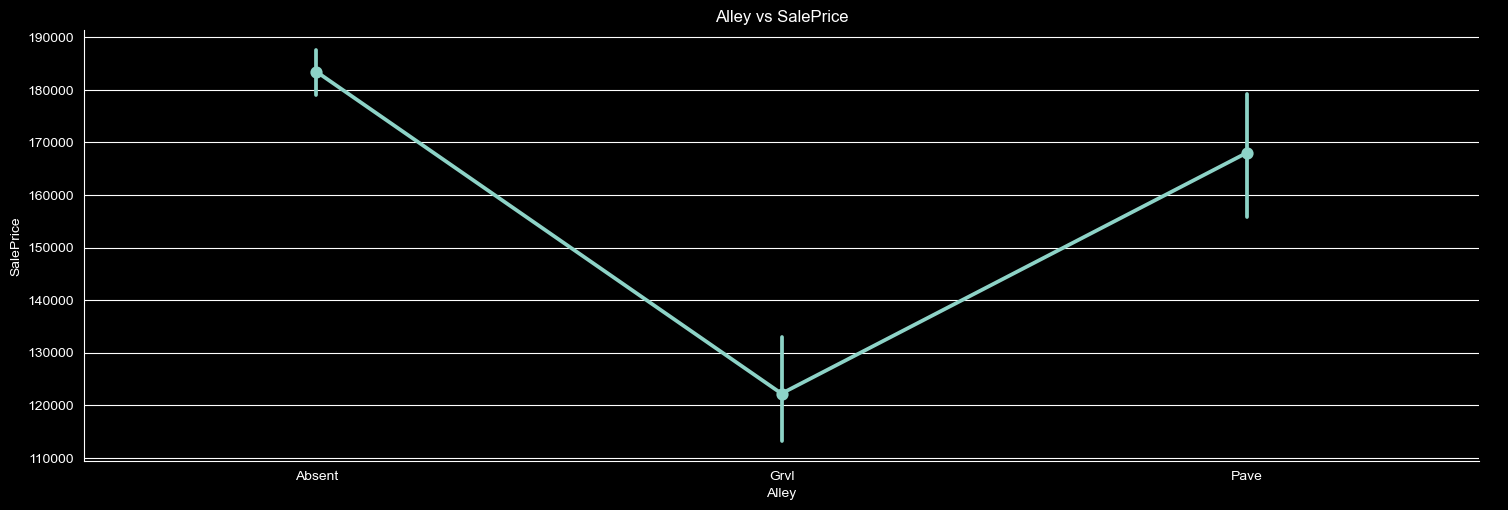

In [92]:
sns.catplot(data=df,
            x='Alley',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=3)
plt.title('Alley vs SalePrice')
plt.show()

## LotShape
Общая форма объекта недвижимости \[прямоугольник / не прямоугольник].

Признаков ещё много, а время ограниченно.\
Далее идёт признаки, имеющие не такую большую значимость как *MSSubClass*, *LotArea* и т.п.\
Поэтому я буду смотреть на распределения и зависимость признаков без какого-то текстового описания. Необычные и важные случаи буду рассматривать подробнее.

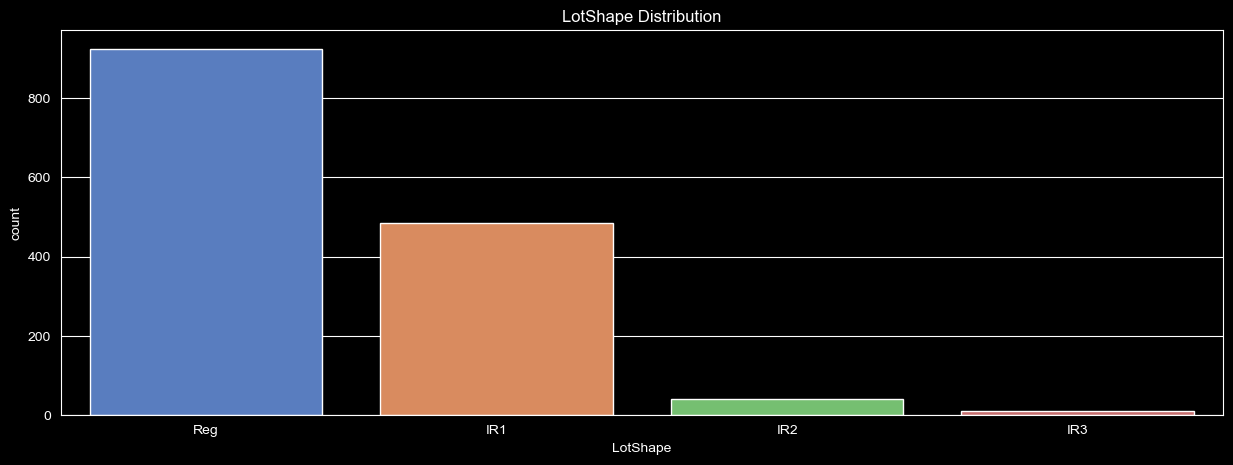

In [93]:
plt.figure(figsize = (15,5))
sns.countplot(data=df, x='LotShape', palette='muted')
plt.title('LotShape Distribution')
plt.show()

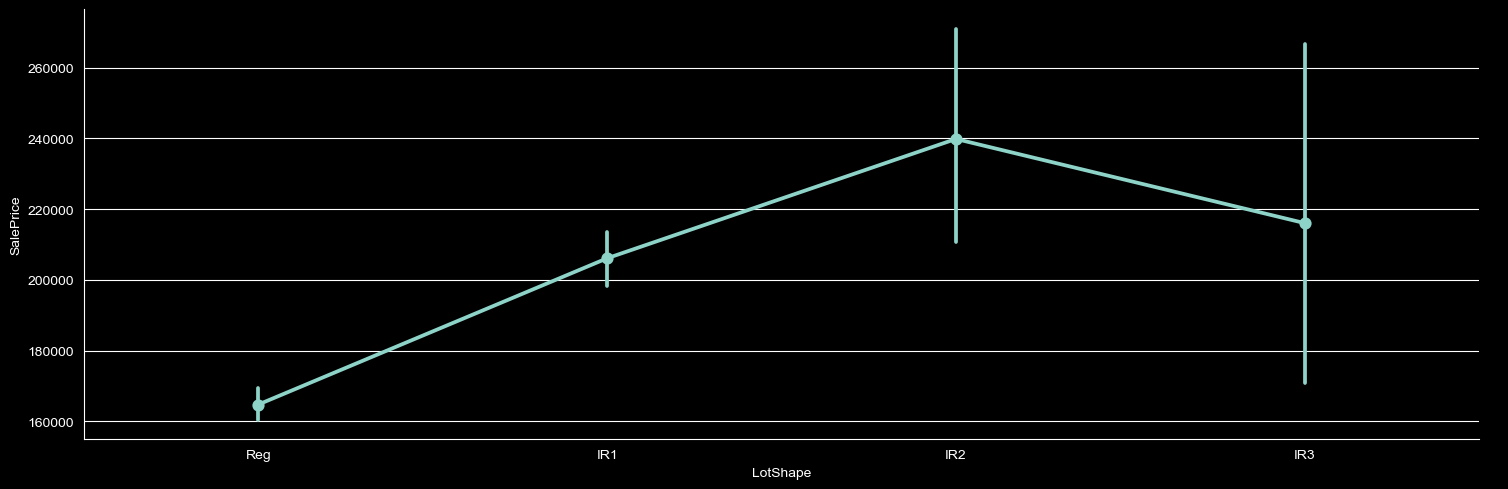

In [94]:
sns.catplot(data=df,
            x='LotShape',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=3)
plt.show()

In [95]:
print(f'Count IR1 is {df[df['LotShape'] == 'IR1'].shape[0]} \nCount IR2 is {df[df['LotShape'] == 'IR2'].shape[0]} \nCount IR3 is {df[df['LotShape'] == 'IR3'].shape[0]}')

Count IR1 is 484 
Count IR2 is 41 
Count IR3 is 10


Признак **LotShape** показывает форму земельного участка, и значение *Reg* означает правильную форму. Остальные означают отклонения от нормы.\
По логике, участники с правильной формой должны стоит дороже. Но по факту получается, что дома с неправильной формой имеют большую площадь участка, от чего и вырастает их стоимость:


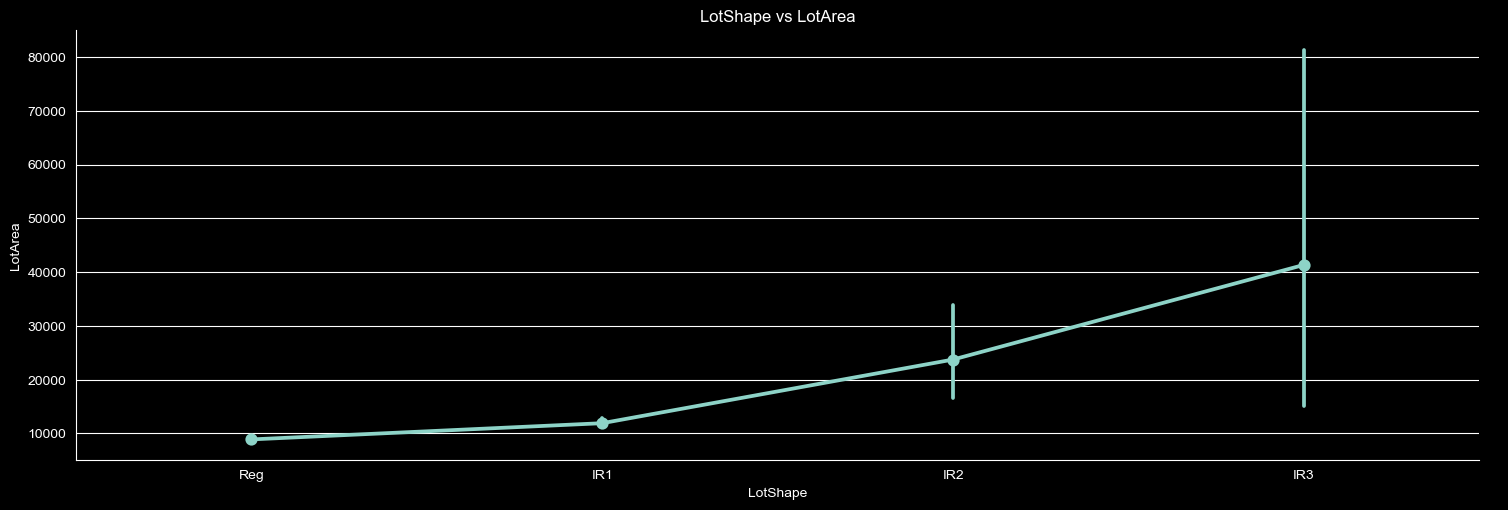

In [96]:
sns.catplot(data=df,
            x='LotShape',
            y='LotArea',
            kind='point',
            height=5,
            aspect=3)
plt.title('LotShape vs LotArea')
plt.show()

Но цена у домов с *IR3* падает. В датасете всего-лишь 10 объектов со значением *IR3* + данное значение показывает очень неровный участок.\
Возможно участки с таким значением настолько неправильный, что на них уже просто невозможно стоить дом, отчего и падает цена.

## LandContour
Показывает ровность участка:
- Lvl — почти ровный;
- Bnk — значительный подъём от улицы до здания;
- HLS — значительный уклон с одной стороны на другую.
- Low — низина / впадина.

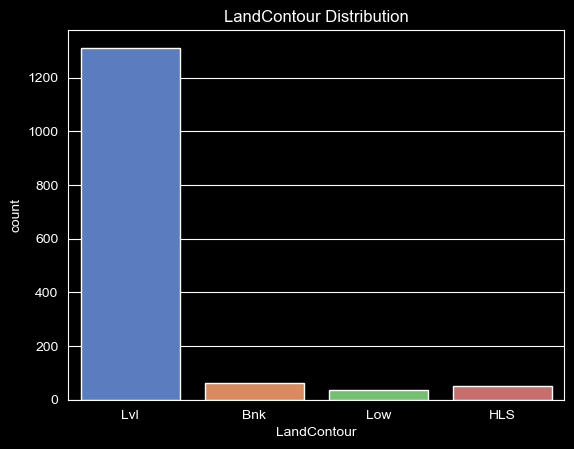

In [97]:
sns.countplot(data=df, x='LandContour', palette='muted')
plt.title('LandContour Distribution')
plt.show()

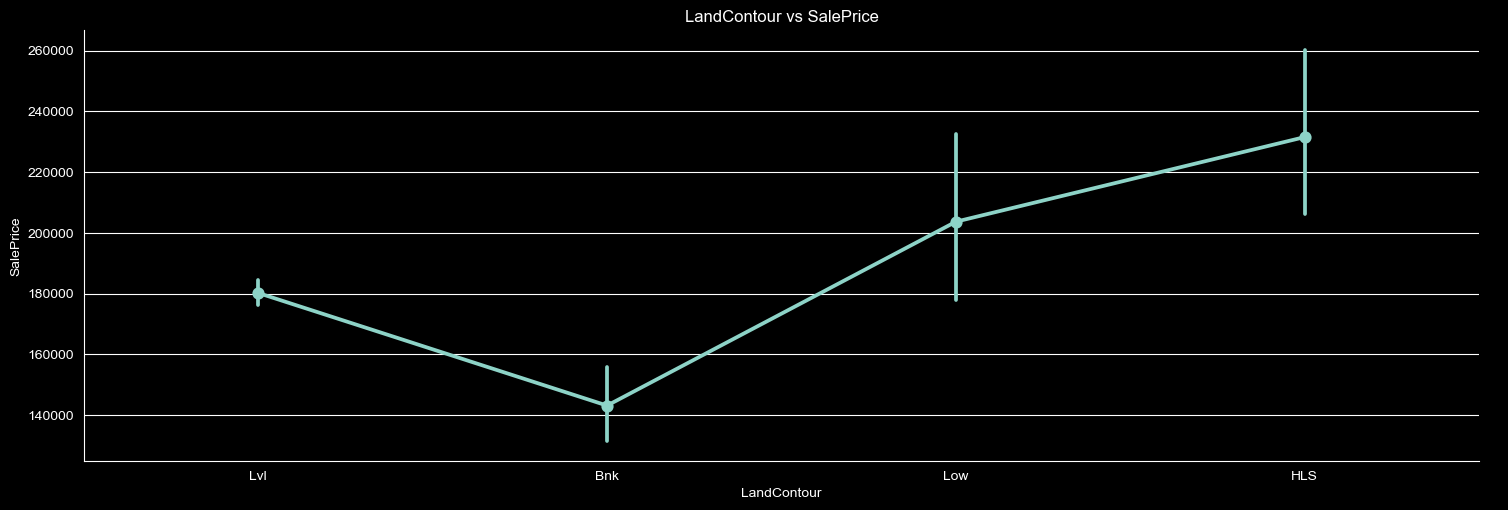

In [98]:
sns.catplot(data=df,
            x='LandContour',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=3)
plt.title('LandContour vs SalePrice')
plt.show()

Интересно: дома со значением *Lvl* далеки от лучшей стоимости, хотя строить дом в них легче всего.
Значение *Low* означает нахождение дома во впадение и во время дождя вся вода будет скапливаться под домом + вид красивый отсутствует.
Сходу объяснить такое поведение очень тяжело.

In [99]:
print(f'Count Lvl is {df[df['LandContour'] == 'Lvl'].shape[0]:>4}\n'
      f'Count Bnk is {df[df['LandContour'] == 'Bnk'].shape[0]:>4}\n'
      f'Count Low is {df[df['LandContour'] == 'Low'].shape[0]:>4}\n'
      f'Count HLS is {df[df['LandContour'] == 'HLS'].shape[0]:>4}\n')

Count Lvl is 1311
Count Bnk is   63
Count Low is   36
Count HLS is   50



Видно, что сэмплов у *Bnk*, *Low*, *HLS* слишком мало, чтобы дать объективную оценку + среднее значение площади участка заметно больше, что и влияет на цену.\
Также у этих редких значений слишком большой разброс, из-за чего тоже тяжело сделать логические выводы.

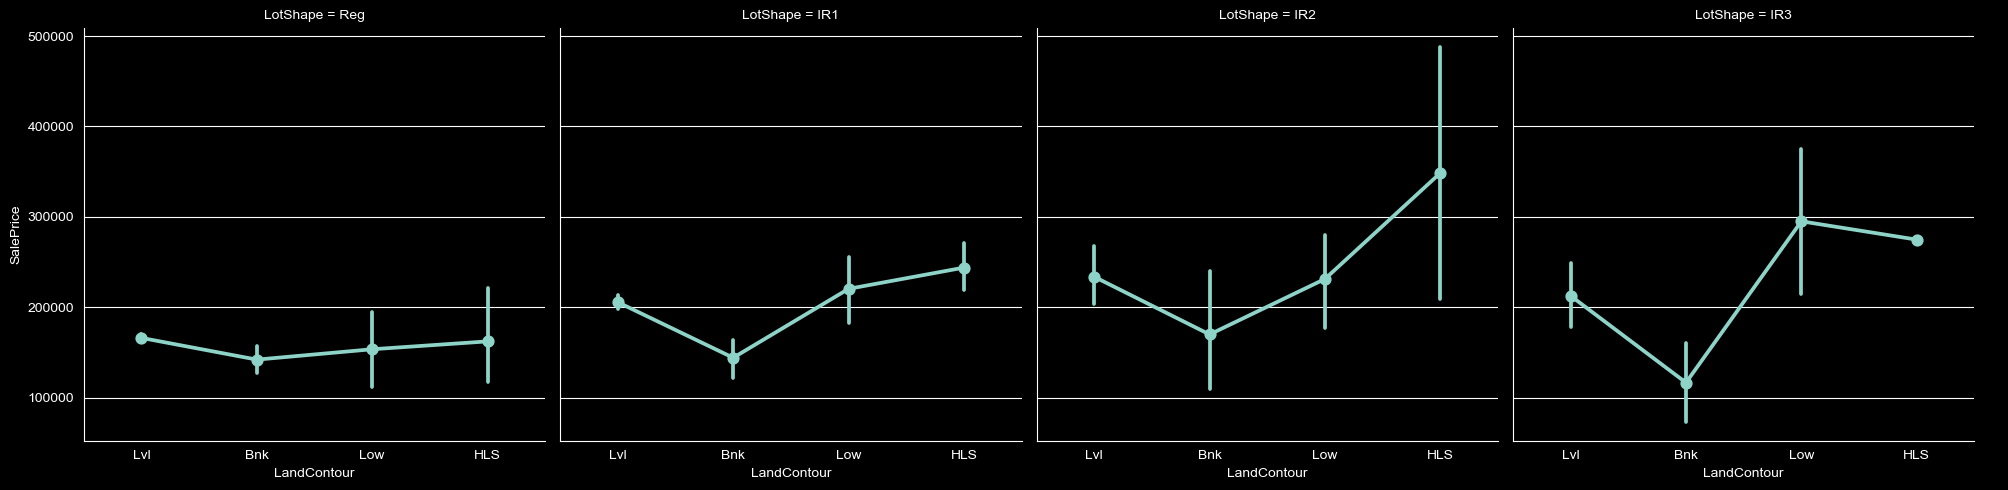

In [100]:
sns.catplot(data=df,
            x='LandContour',
            y='SalePrice',
            col='LotShape',
            kind='point')
plt.show()

Если добавить в рассмотрение признак *LotShape*, можно увидеть, что у прямоугольных участков цена более-менее одинаковая и к ним вопросов нет.\
У других домов с неровностями начинается непонятный разброс при разном ландшафте. Связи никакой не вижу.

## Utilities
Показывает виды доступных коммунальных услуг.

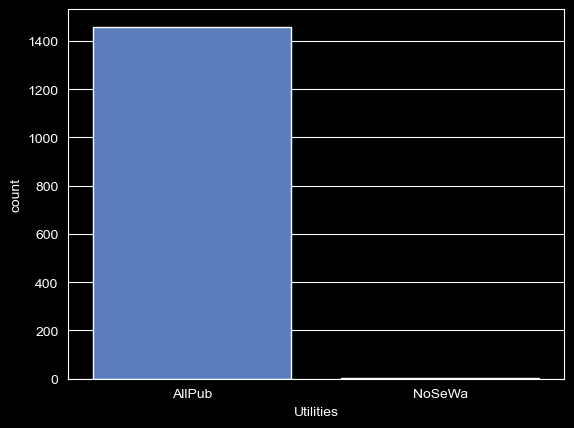

In [101]:
sns.countplot(data=df, x='Utilities', palette='muted')
plt.show()

In [102]:
print(f'Count NoSeWa is {df[df['Utilities'] == 'NoSeWa'].shape[0]}')

Count NoSeWa is 1


Лишь один дом имеет не полные коммунальные услуги. Влияние на таргет минимальное.

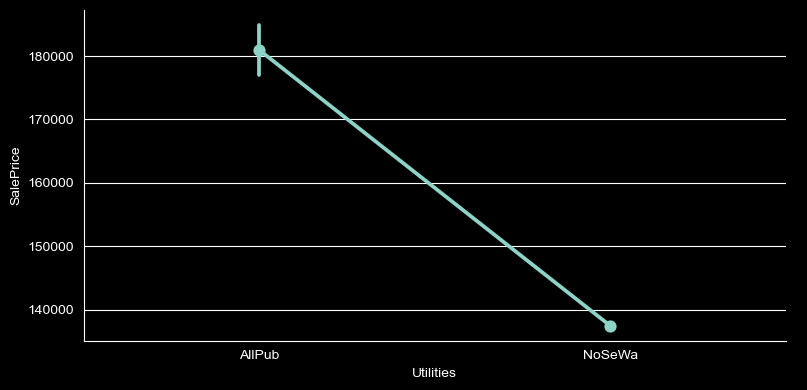

In [103]:
sns.catplot(data=df,
            x='Utilities',
            y='SalePrice',
            kind='point',
            height=4,
            aspect=2)
plt.show()

## LotConfig
Конфигурация участка:
- Inside — внутренний участок (соседи с 3-х сторон, 1 сторона у дороги);
- Corner — угловой участок на пересечении 2-х улиц;
- CulDSac — участок в глухом тупике;
- FR2 — сквозной участок (выход на 2 улицы);
- FR3 — участок окружён дорогой с 3-х сторон.

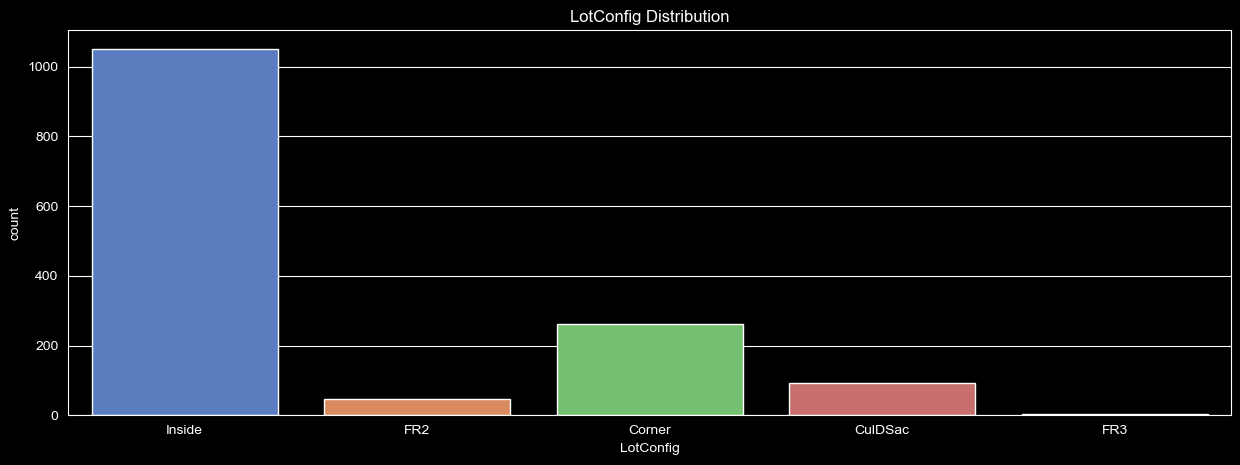

In [104]:
plt.figure(figsize = (15,5))
sns.countplot(data=df, x='LotConfig', palette='muted')
plt.title('LotConfig Distribution')
plt.show()

In [105]:
pd.crosstab(index=df['LotConfig'],
            columns=df['LotConfig'].count(),
            colnames=['Count']
).style.background_gradient(cmap='coolwarm')

Count,1460
LotConfig,
Corner,263
CulDSac,94
FR2,47
FR3,4
Inside,1052


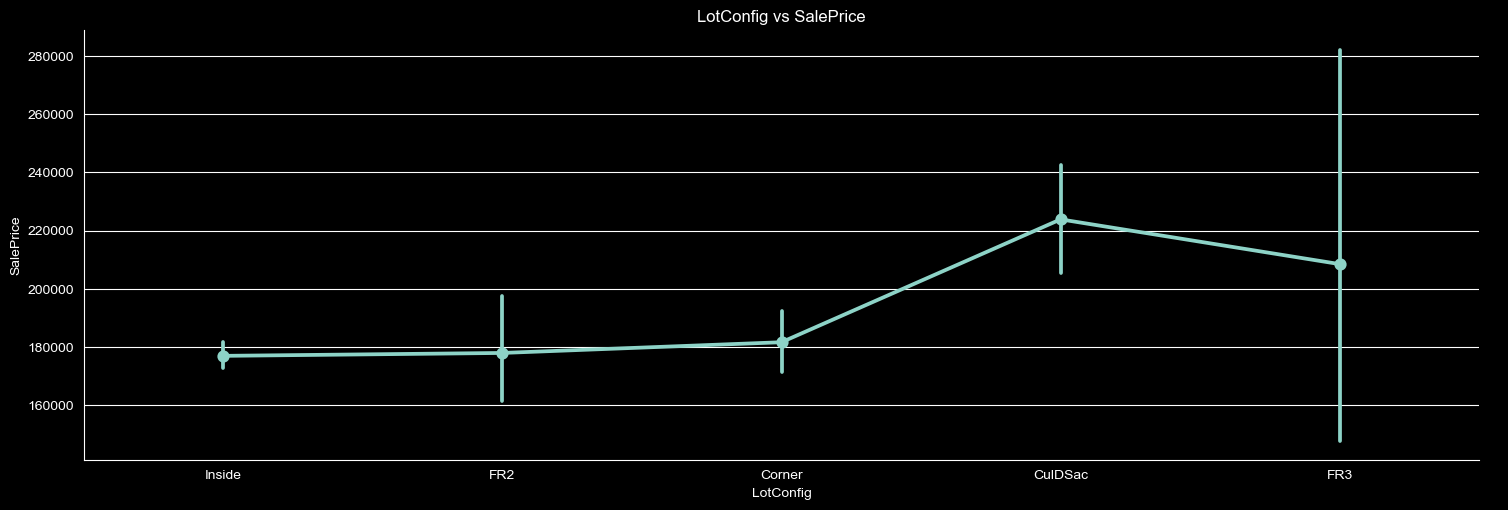

In [106]:
sns.catplot(data=df,
            x='LotConfig',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=3)
plt.title('LotConfig vs SalePrice')
plt.show()

Домов с *FR3* всего 4 штуки, поэтому такой болшой разброс. А вот *CulDSac* действтиельно должен быть дороже всех, т.к. является тихимим, спокойным и большим участком.

## LandSlope
Наклон участка.
- Gtl — пологий наклон;
- Mod — умеренный уклон;
- Sev — крутой склон.

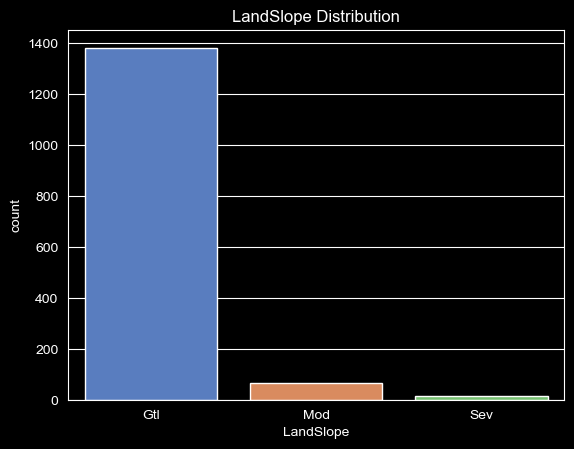

In [107]:
sns.countplot(data=df, x='LandSlope', palette='muted')
plt.title('LandSlope Distribution')
plt.show()

In [108]:
pd.crosstab(index=df['LandSlope'],
            columns=df['LandSlope'].count(),
            colnames=['Count']
).style.background_gradient(cmap='coolwarm')

Count,1460
LandSlope,
Gtl,1382
Mod,65
Sev,13


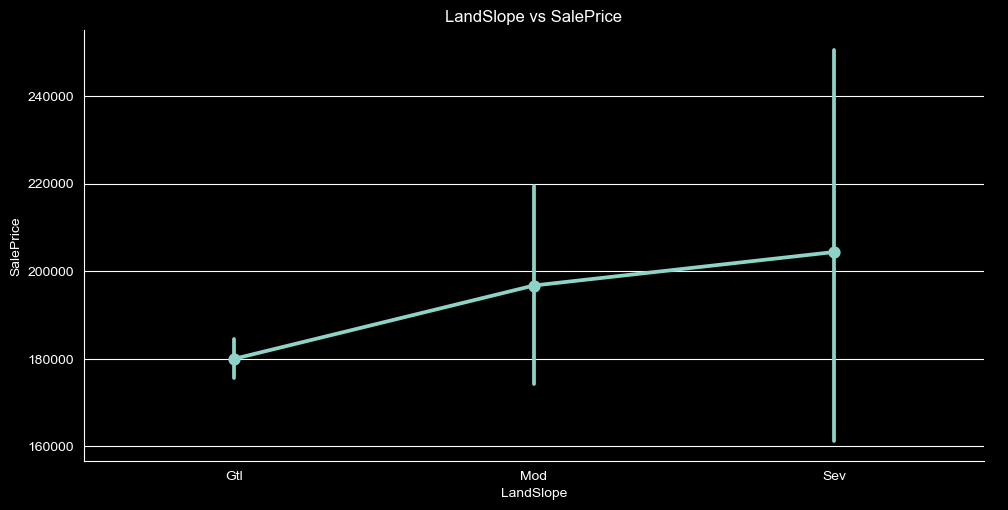

In [109]:
sns.catplot(data=df,
            x='LandSlope',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('LandSlope vs SalePrice')
plt.show()

Сэмплов слишком мало, чтобы сделать объективную оценку умеренных и крутых склонов. Но можно проверить площадь участков и убедиться, что у участков со склоном большая площадь:

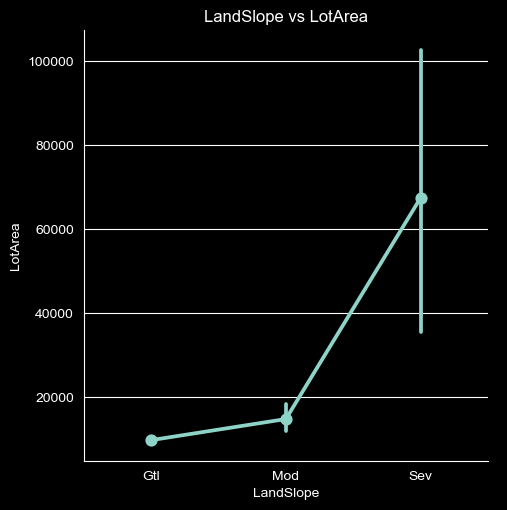

In [110]:
sns.catplot(data=df,
            x='LandSlope',
            y='LotArea',
            kind='point')
plt.title('LandSlope vs LotArea')
plt.show()

## Neighborhood
Район расположения участка.

Элитные:
- NoRidge;
- NridgHt;
- StoneBr.

Высокий класс:
- Timber;
- Veenker;
- Somerst;
- ClearCr;
- Crawfor.

Средний класс:
- CollgCr;
- Blmngtn;
- NWAmes;
- SawyerW;
- Gilbert;
- Mitchel;
- NPkVill;
- NAmes.

Бюджетные:
- Sawyer;
- SWISU;
- Blueste;
- BrkSide;
- Edwards;
- OldTown;
- BrDale.

Низкий класс:
- IDOTRR;
- MeadowV.

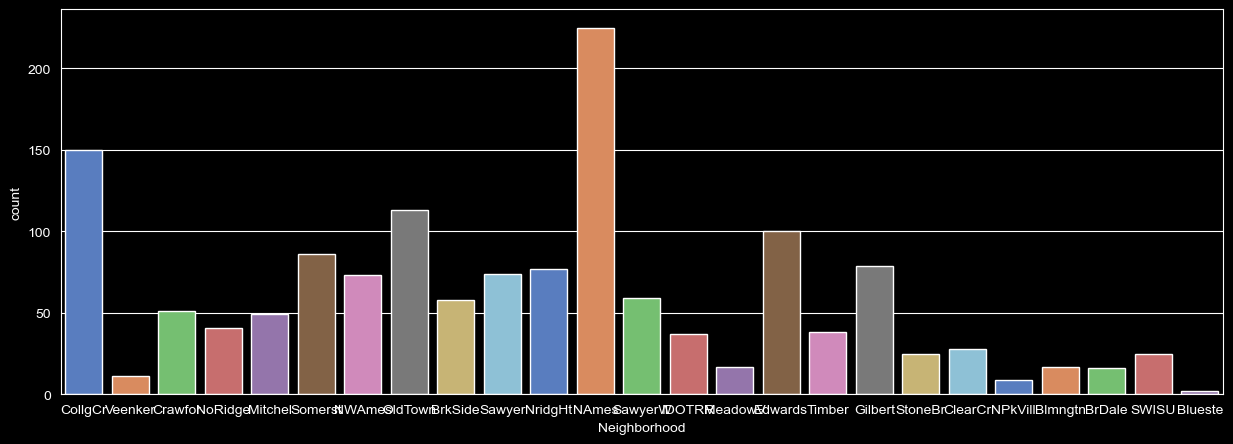

In [111]:
plt.figure(figsize = (15,5))
sns.countplot(data=df, x='Neighborhood', palette='muted')
plt.show()

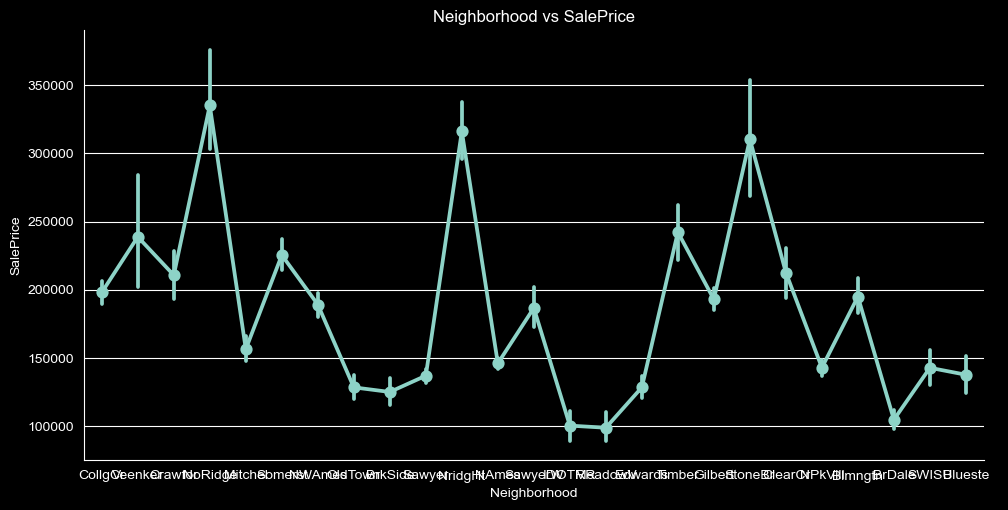

In [112]:
sns.catplot(data=df,
            x='Neighborhood',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('Neighborhood vs SalePrice')
plt.show()

В принципе, видна корреляция между классом района и стоимостью. жилья.\
Для лушчей наглядности и будущего фича-инженеринга присвоим класс каждому сэмплу:

In [113]:
df['Neighborhood_Class'] = 'Absent'
highest_neighborhood = ['NoRidge', 'NridgHt', 'StoneBr']
high_neighborhood = ['Timber', 'Veenker', 'Somerst', 'ClearCr', 'Crawfor']
medium_neighborhood = ['CollgCr', 'Blmngtn', 'NWAmes', 'SawyerW', 'Gilbert', 'Mitchel', 'NPkVill', 'NAmes']
low_neighborhood = ['Sawyer', 'SWISU', 'Blueste', 'BrkSide', 'Edwards', 'OldTown', 'BrDale']
lowest_neighborhood = ['IDOTRR', 'MeadowV']

df.loc[df['Neighborhood'].isin(highest_neighborhood), 'Neighborhood_Class'] = 'Highest'
df.loc[df['Neighborhood'].isin(high_neighborhood), 'Neighborhood_Class'] = 'High'
df.loc[df['Neighborhood'].isin(medium_neighborhood), 'Neighborhood_Class'] = 'Medium'
df.loc[df['Neighborhood'].isin(low_neighborhood), 'Neighborhood_Class'] = 'Low'
df.loc[df['Neighborhood'].isin(lowest_neighborhood), 'Neighborhood_Class'] = 'Lowest'

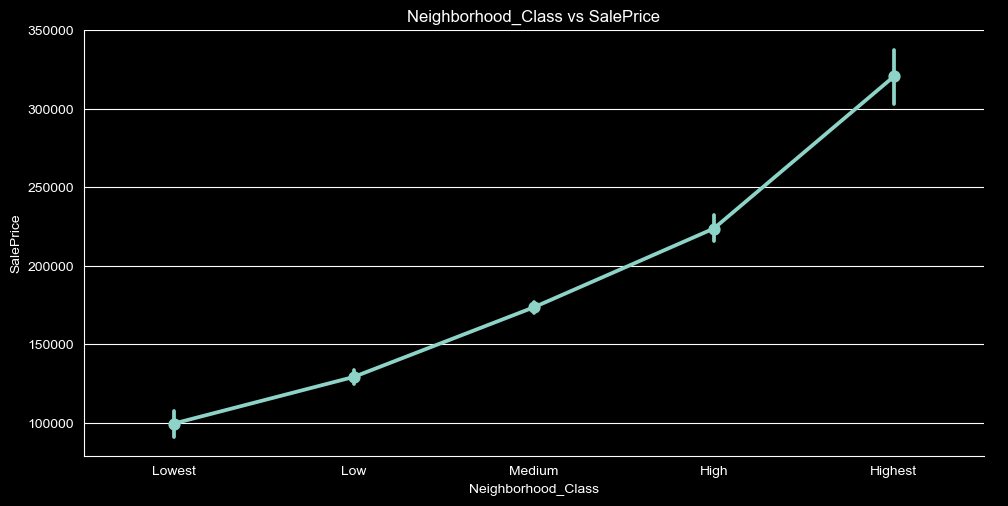

In [114]:
sns.catplot(data=df,
            x='Neighborhood_Class',
            order=['Lowest', 'Low', 'Medium', 'High', 'Highest'],
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('Neighborhood_Class vs SalePrice')
plt.show()

## Condition1
Близость к объектам инфраструктуры:
- PosA / PosN — рядом с парком;
- Norm — обычные жилищные условия;
- Artery / Feedr — примыкает к главной магистрали;
- RRNn / RRAn / RRNe / RRAe — рядом с ж/д путями.

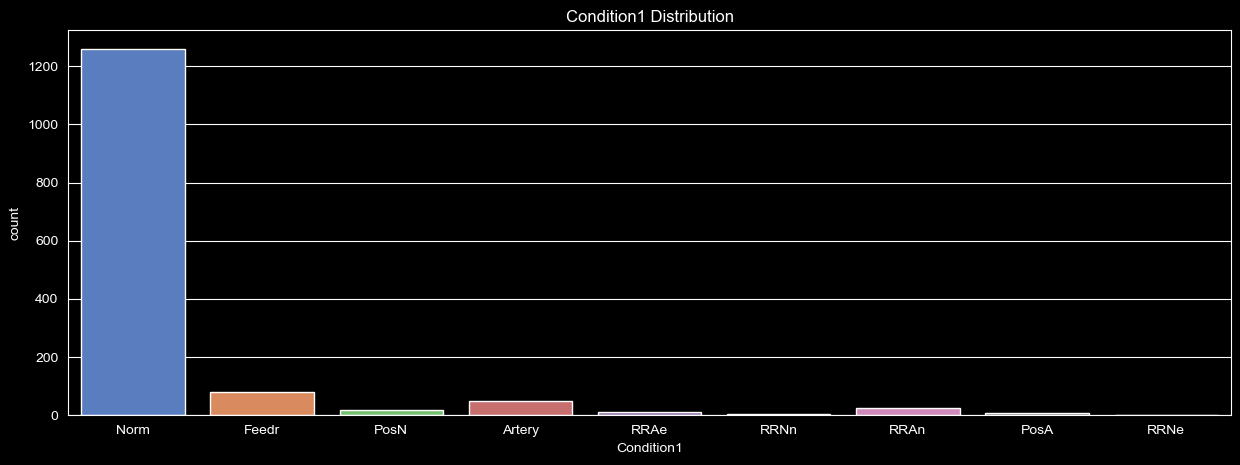

In [115]:
plt.figure(figsize = (15, 5))
sns.countplot(data=df, x='Condition1', palette='muted')
plt.title('Condition1 Distribution')
plt.show()

In [116]:
pd.crosstab(index=df['Condition1'],
            columns=df['Condition1'].count(),
            colnames=['Count']
).style.background_gradient(cmap='coolwarm')

Count,1460
Condition1,
Artery,48
Feedr,81
Norm,1260
PosA,8
PosN,19
RRAe,11
RRAn,26
RRNe,2
RRNn,5


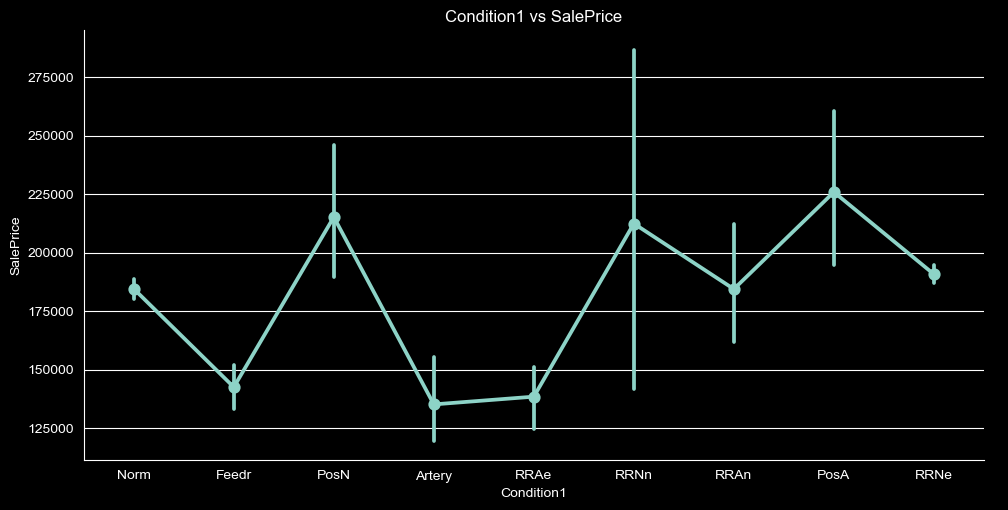

In [117]:
sns.catplot(data=df,
            x='Condition1',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('Condition1 vs SalePrice')
plt.show()

Хороший показатель у домов с *RRNn*, хотя условия для проживания очень плохие. Домов всего 5, поэтому не удивительно, что такой большой разброс и такая цена.
Аналогичная ситуация с домами *RRAn*.

Разобьём их на классы:

In [118]:
good_condition1 = ['PosN', 'PosA']
normal_condition1 = ['Norm']
fair_condition = ['Artery', 'Feedr']
poor_condition1 = ['RRNn', 'RRAn', 'RRNe', 'RRAe']

df['Condition1_Class'] = 'Absent'

df.loc[df['Condition1'].isin(good_condition1), 'Condition1_Class'] = 'Good'
df.loc[df['Condition1'].isin(normal_condition1), 'Condition1_Class'] = 'Normal'
df.loc[df['Condition1'].isin(fair_condition), 'Condition1_Class'] = 'Fair'
df.loc[df['Condition1'].isin(poor_condition1), 'Condition1_Class'] = 'Poor'

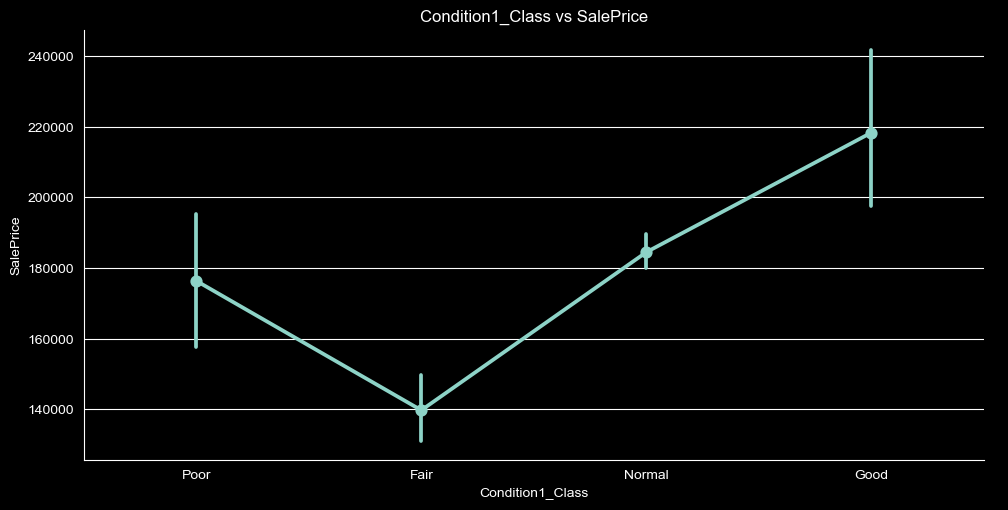

In [119]:
sns.catplot(data=df,
            x='Condition1_Class',
            order=['Poor', 'Fair', 'Normal', 'Good'],
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('Condition1_Class vs SalePrice')
plt.show()

Очень интересно получается: дома с плохими условиями в среднем стоят дороже, чем дома с более-менее нормальными.

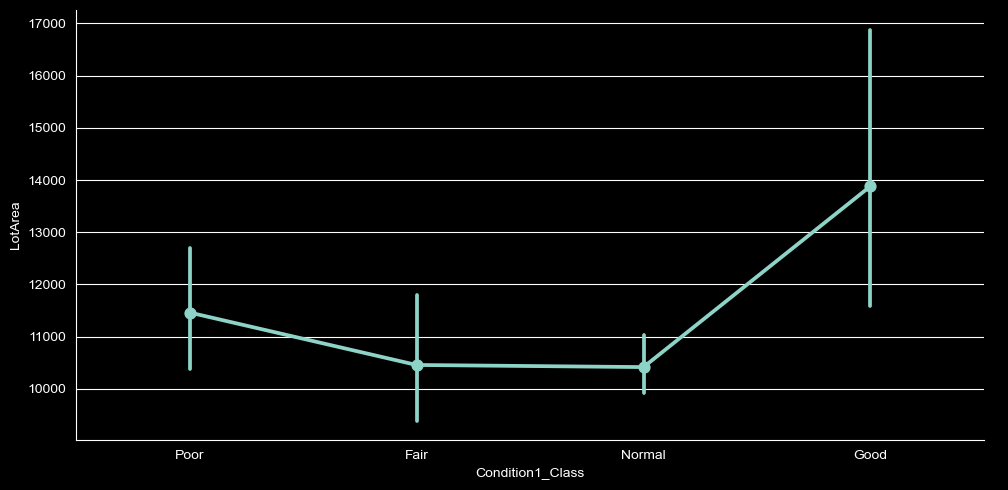

In [120]:
sns.catplot(data=df,
            x='Condition1_Class',
            order=['Poor', 'Fair', 'Normal', 'Good'],
            y='LotArea',
            kind='point',
            height=5,
            aspect=2)
plt.show()

Предположу: цена у домов с плохими условиями больше, чем у справедливых и нормальных, за счёт высокой площади участка.

## Condition2
Абсолютно аналогичное условие с *Condition2*, ничего нового из анализа не узнаю.\
Но на этапе фича-инженеренга будет полезло как-нибудь скомбинировать оба данных признака.

## BldgType
Тип жилья.
- 1Fam — изолированный дом для 1-ой семьи;
- 2FmCon — дом для 2-ух семей, изначально построеннй для одной;
- Duplex — дом для 2-ух семей, разделённый пополам с разными входами;
- TwnhsE — таунхаус, дом скраю;
- TwnhsI — таунхаус, дом внутри.

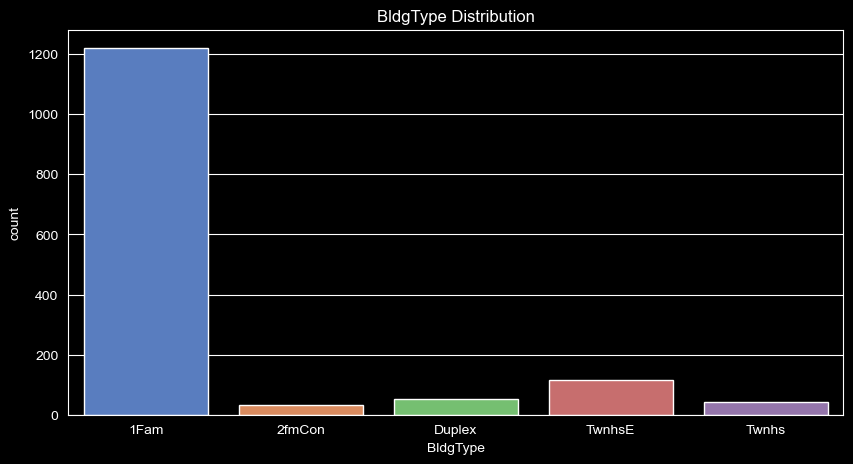

In [121]:
plt.figure(figsize = (10, 5))
sns.countplot(data=df, x='BldgType', palette='muted')
plt.title('BldgType Distribution')
plt.show()

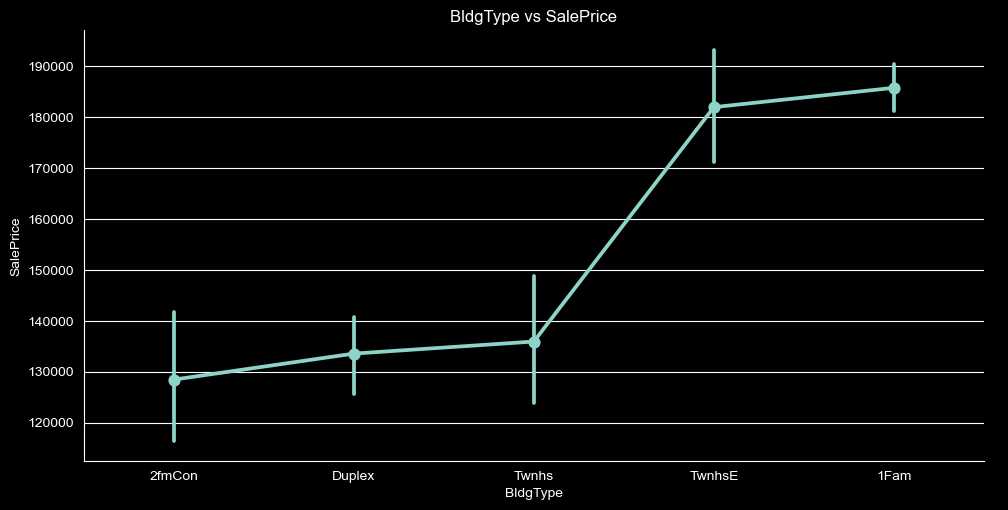

In [122]:
sns.catplot(data=df,
            x='BldgType',
            order=['2fmCon', 'Duplex', 'Twnhs', 'TwnhsE', '1Fam'],
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('BldgType vs SalePrice')
plt.show()

## HouseStyle
Архитектурная конфигурация дома.
- 1Story — 1-этажное здание;
- 1.5Fin — 1.5-этажное здание, мансарда завершена;
- 1.5Unf — 1.5-этажное здание, мансарда не завершена;
- 2Story — 2-этажное здание;
- 2.5Fin — 2.5-этажное здание, мансарда завершена;
- 2.5Unf — 2.5-этажное здание, мансарда не завершена;
- SFoyer — вход на промежуточном уровне;
- SLvl — разноуровневые комнаты.

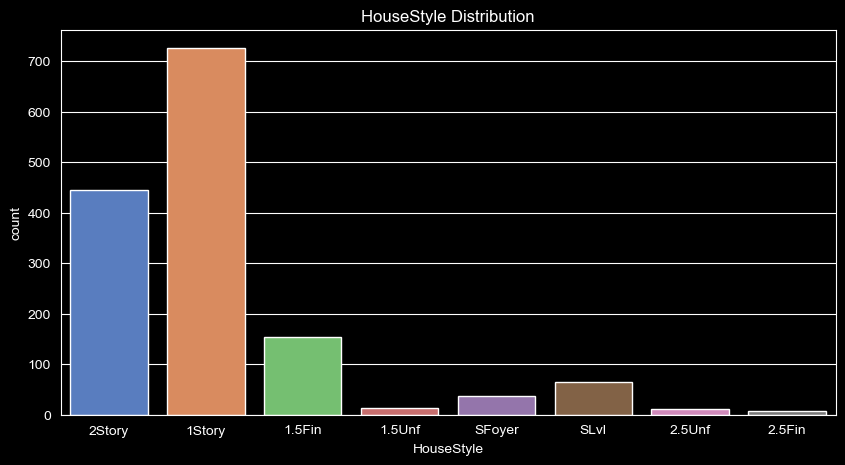

In [123]:
plt.figure(figsize = (10, 5))
sns.countplot(data=df, x='HouseStyle', palette='muted')
plt.title('HouseStyle Distribution')
plt.show()

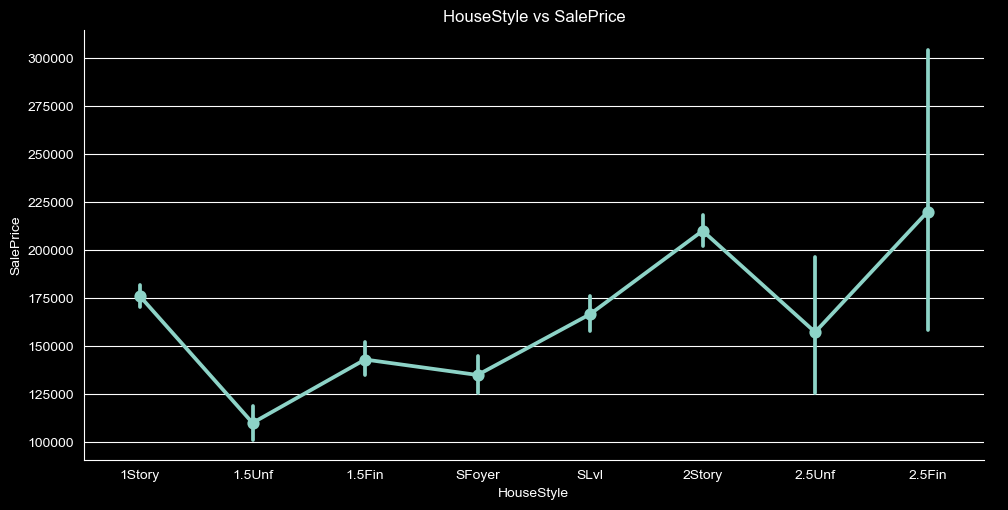

In [124]:
sns.catplot(data=df,
            x='HouseStyle',
            order=['1Story', '1.5Unf', '1.5Fin', 'SFoyer', 'SLvl', '2Story', '2.5Unf', '2.5Fin'],
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('HouseStyle vs SalePrice')
plt.show()

Интересное наблюдение: 1-этажные дома стоят заметно дороже, чем 1.5-этажные, а 2-этажные практически столько же, сколько 2.5-этажные.
При этом за недоделанную мансарду цена на жельё заметно падает.

## RoofStyle
Тип крыши.
- Flat — плоская;
- Gable — двускатная (2 наклонных ската);
- Gambrel — амбарная (с изломом ската);
- Hip — четырёхскатная (4 ската со всех сторон);
- Mansard — в основном двускатная крыша, с крутым нижнем скатом и почти плоским сверху;
- Shed — односкатная.

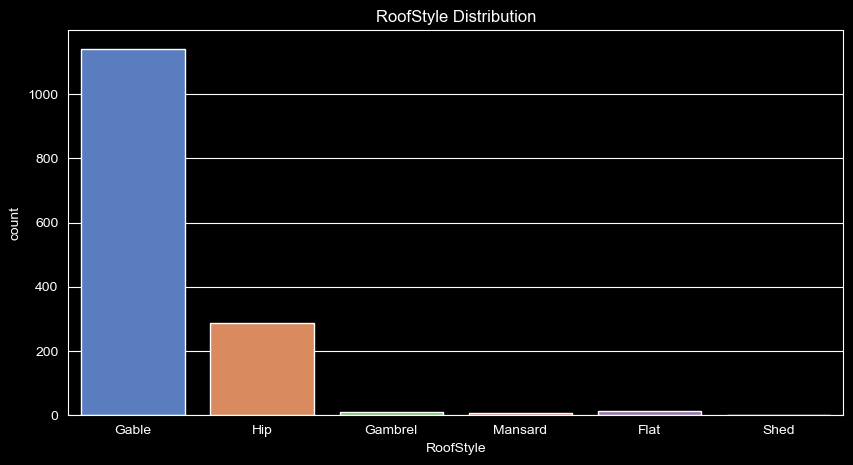

In [125]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='RoofStyle', palette='muted')
plt.title('RoofStyle Distribution')
plt.show()

In [126]:
pd.crosstab(index=df['RoofStyle'],
            columns=df['RoofStyle'].count(),
            colnames=['Count']
).style.background_gradient(cmap='coolwarm')

Count,1460
RoofStyle,
Flat,13
Gable,1141
Gambrel,11
Hip,286
Mansard,7
Shed,2


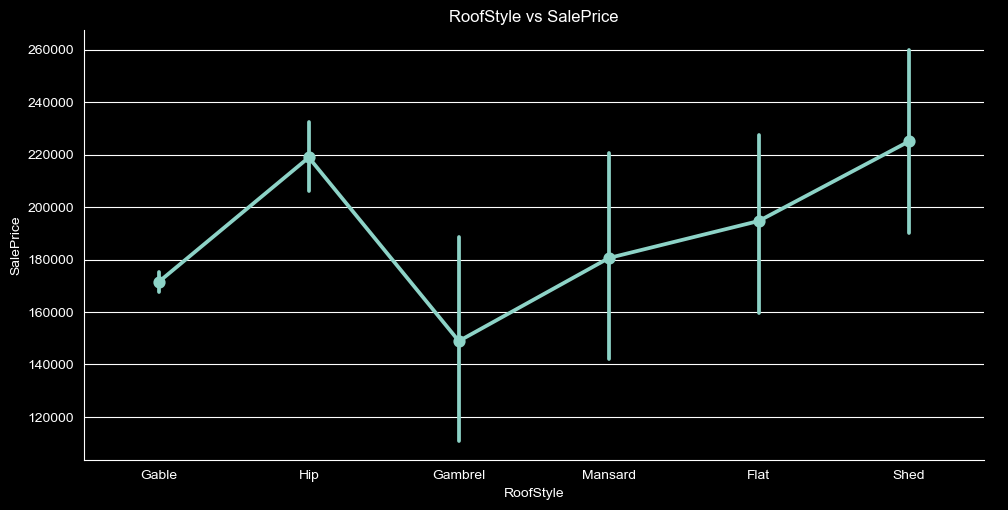

In [127]:
sns.catplot(data=df,
            x='RoofStyle',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('RoofStyle vs SalePrice')
plt.show()

Большинство домов имеют крышу *Shed* и *Hip*, отчего и получается такой график.

Более интересен факт, что домов с мансардной крышой всего 7, но 1.5-этажные и 2.5-этажные дома подразумевают наличие мансарды.
Интересно, какой тип крыши у 1.5-этажных и 2.5-этажных домов:

In [128]:
mansard_dwelling = ['1.5Fin', '1.5Unf', '2.5Fin', '2.5Unf']
df[df['HouseStyle'].isin(mansard_dwelling)]['RoofStyle'].unique().tolist()

['Gable', 'Hip', 'Gambrel', 'Shed']

Забавно, ни один дом с мансардой не имеет мансардную крышу. Интересное, какие дома тогда имеют данную крышу:

In [129]:
df[df['RoofStyle'] == 'Mansard']

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LotFrontage_Group,LotArea_Group,Neighborhood_Class,Condition1_Class
106,107,30,RM,60.0,10800,Pave,Grvl,Reg,Lvl,AllPub,...,450,8,2007,WD,Normal,100000,40,10,Low,Normal
298,299,60,RL,90.0,11700,Pave,Absent,Reg,Lvl,AllPub,...,0,6,2007,WD,Normal,175000,80,10,Medium,Normal
324,325,80,RL,96.0,11275,Pave,Absent,Reg,Lvl,AllPub,...,0,6,2010,WD,Normal,242000,80,10,Medium,Good
471,472,60,RL,92.0,11952,Pave,Absent,Reg,Lvl,AllPub,...,0,11,2007,WD,Normal,190000,80,10,Medium,Good
643,644,60,RL,80.0,10793,Pave,Absent,Reg,Lvl,AllPub,...,0,4,2007,WD,Normal,152000,60,10,Medium,Poor
747,748,70,RM,65.0,11700,Pave,Pave,IR1,Lvl,AllPub,...,0,5,2009,WD,Normal,265979,60,10,Low,Normal
1283,1284,90,RL,94.0,9400,Pave,Absent,Reg,Low,AllPub,...,0,4,2010,WD,Normal,139000,80,5,Medium,Normal


Данные дома ничего не выделяются, но имеют достаточно хорошу стоимость.

## RoofMatl
Материал крыши.
- ClyTile — глиняная / керамическая черепица;
- CompShg — битумная / мягкая черепица;
- Membran — полимерная гидромембрана;
- Metal — металлочерепица / металлонастил;
- Roll — рулонный рубероид;
- Tar&Grv — гудрон и гравий;
- WdShake — колотая деревянная дранка;
- WdShngl — пилённая деревянная черепица.

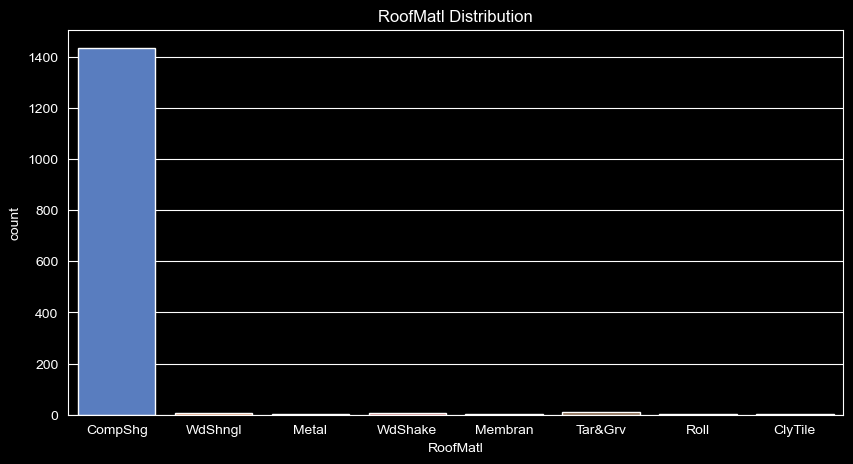

In [130]:
plt.figure(figsize = (10, 5))
sns.countplot(data=df, x='RoofMatl', palette='muted')
plt.title('RoofMatl Distribution')
plt.show()

In [131]:
pd.crosstab(index=df['RoofMatl'],
            columns=df['RoofMatl'].count(),
            colnames=['Count']
).style.background_gradient(cmap='coolwarm')

Count,1460
RoofMatl,
ClyTile,1
CompShg,1434
Membran,1
Metal,1
Roll,1
Tar&Grv,11
WdShake,5
WdShngl,6


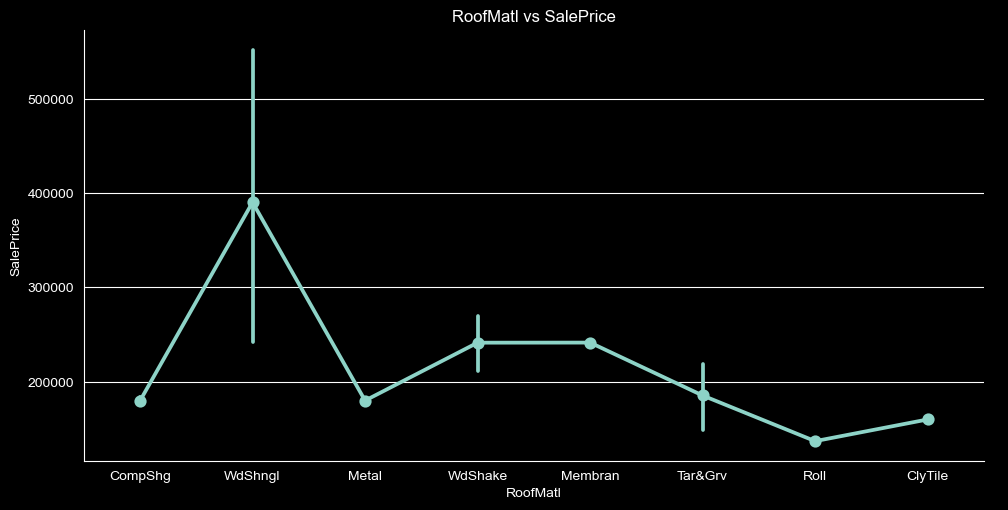

In [132]:
sns.catplot(data=df,
            x='RoofMatl',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('RoofMatl vs SalePrice')
plt.show()

Данных слишком мало. Почти все дома используют битумную черепицу.

In [133]:
df[df['RoofMatl'] != 'CompShg']

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LotFrontage_Group,LotArea_Group,Neighborhood_Class,Condition1_Class
53,54,20,RL,68.0,50271,Pave,Absent,IR1,Low,AllPub,...,0,11,2006,WD,Normal,385000,60,40,High,Normal
120,121,80,RL,NaN,21453,Pave,Absent,IR1,Low,AllPub,...,0,10,2006,WD,Normal,180000,NaN,20,High,Normal
169,170,20,RL,NaN,16669,Pave,Absent,IR1,Lvl,AllPub,...,0,1,2006,WD,Normal,228000,NaN,15,High,Normal
185,186,75,RM,90.0,22950,Pave,Absent,IR2,Lvl,AllPub,...,0,6,2006,WD,Normal,475000,80,20,Low,Fair
271,272,20,RL,73.0,39104,Pave,Absent,IR1,Low,AllPub,...,0,4,2008,WD,Normal,241500,60,30,High,Normal
324,325,80,RL,96.0,11275,Pave,Absent,Reg,Lvl,AllPub,...,0,6,2010,WD,Normal,242000,80,10,Medium,Good
367,368,80,RL,101.0,9150,Pave,Absent,IR1,Lvl,AllPub,...,0,12,2008,WD,Normal,165000,100,5,Medium,Normal
451,452,20,RL,62.0,70761,Pave,Absent,IR1,Low,AllPub,...,0,12,2006,WD,Normal,280000,60,40,High,Normal
457,458,20,RL,NaN,53227,Pave,Absent,IR1,Low,AllPub,...,0,3,2008,WD,Normal,256000,NaN,40,High,Normal
466,467,20,RL,85.0,10628,Pave,Absent,Reg,Lvl,AllPub,...,0,4,2007,WD,Normal,167000,80,10,Medium,Normal


Если посмотреть на сэмплы, которые не имеют битумную черепицу, можно заметить,что все они находятся на ровном участке, либо в низине. Возможно использовать битумную черепицу в
низинах невыгодно. Быстрая проверка в интернете подтвердила: битумная черепица быстро покрывается мхом и плесенью  во влажных и тенистых местах, коим и являются низины.

## Exterior1st
Внешняя отделка дома.

Премиальные:
- BrkFace — облицовочный кирпич;
- Stone — натуральный камень;
- CemntBd — цементная плитка;
- Stucco — штукатурка;
- ImStucc — декоративная штукатурка.

Стандарт:
- VinylSd — виниловый сайдинг;
- MetalSd — металлический сайдинг;
- HdBoard — жёсткая доска.

Деревянные (классика 60-х):
- Wd Sdng — деревянные доски;
- Plywood — фанера;
- WdShing — деревянная гонтовая плитка.

Устаревшие / бюджетные:
- AsbShng — асбестовая плитка;
- BrkComm — черновой кирпич;
- AsphShn — асфальтовая черепица;
- CBlock — шлакоблок;
- BrkComm — рядовой кирпич;
- PreCast — железобетонные конструкции;
- Other — другое.

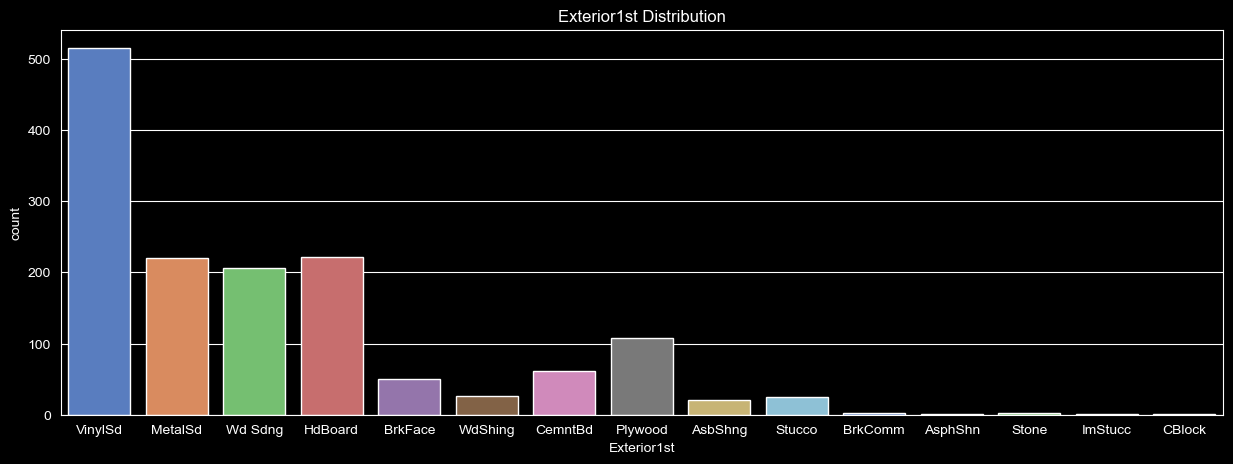

In [136]:
plt.figure(figsize = (15, 5))
sns.countplot(data=df, x='Exterior1st', palette='muted')
plt.title('Exterior1st Distribution')
plt.show()

In [137]:
pd.crosstab(index=df['Exterior1st'],
            columns=df['Exterior1st'].count(),
            colnames=['Count']
).style.background_gradient(cmap='coolwarm')

Count,1460
Exterior1st,
AsbShng,20
AsphShn,1
BrkComm,2
BrkFace,50
CBlock,1
CemntBd,61
HdBoard,222
ImStucc,1
MetalSd,220


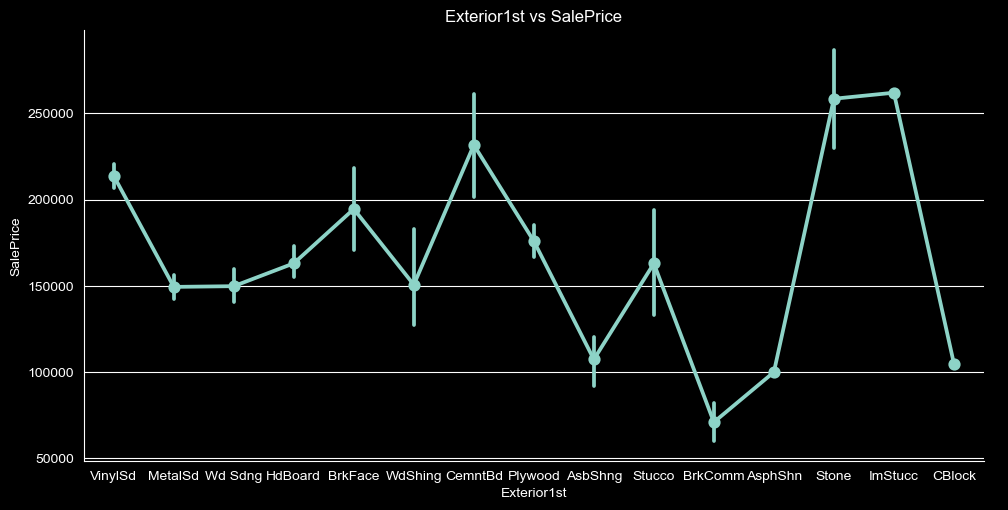

In [138]:
sns.catplot(data=df,
            x='Exterior1st',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('Exterior1st vs SalePrice')
plt.show()

В большинстве значений данных слишком мало, чтобы судить. У *Stone* вообще всего-лишь 2 сэмпла, от чего такой большое отклонение и среднее значение вообще не соответствующее
значениям сэмплов.

Интересно посмотреть на график после разбиения отделок дома на классы:

In [143]:
df['Exterior1st_Class'] = 'Absent'

premium_exterior1st = ['BrkFace', 'Stone', 'CemntBd', 'Stucco', 'ImStucc']
standart_exterior1st = ['VinylSd', 'MetalSd', 'HdBoard']
wooden_exterior1st = ['Wd Sdng', 'Plywood', 'WdShing']
outdated_exterior1st = ['AsbShng', 'BrkComm', 'AsphShn', 'CBlock', 'BrkComm', 'PreCast', 'Other']

df.loc[df['Exterior1st'].isin(premium_exterior1st), 'Exterior1st_Class'] = 'Premium'
df.loc[df['Exterior1st'].isin(standart_exterior1st), 'Exterior1st_Class'] = 'Standart'
df.loc[df['Exterior1st'].isin(wooden_exterior1st), 'Exterior1st_Class'] = 'Wooden'
df.loc[df['Exterior1st'].isin(outdated_exterior1st), 'Exterior1st_Class'] = 'Outdated'

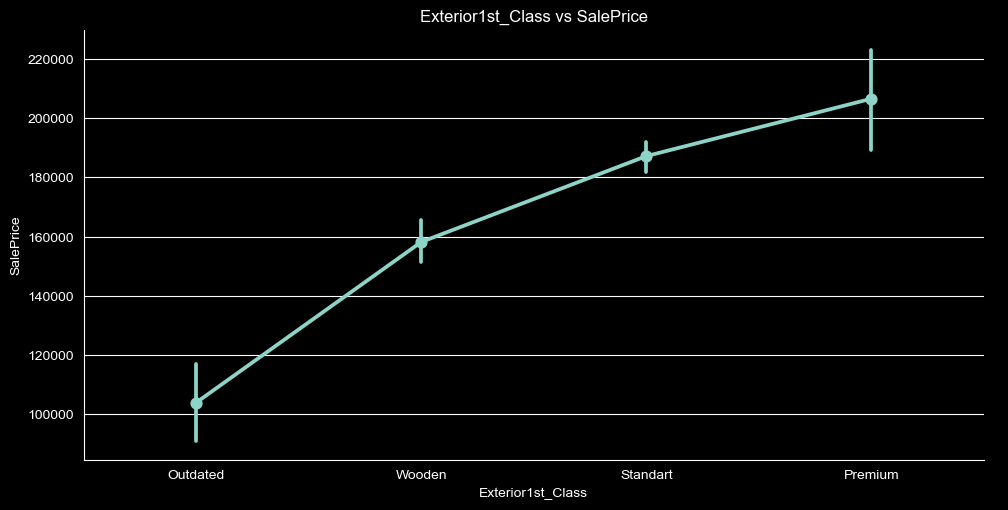

In [147]:
sns.catplot(data=df,
            x='Exterior1st_Class',
            order=['Outdated', 'Wooden', 'Standart', 'Premium'],
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('Exterior1st_Class vs SalePrice')
plt.show()

## Exterior2nd
Признак аналогичный *Exterior1st*. Анализировать его не буду, но фича-инженеринг над ним тоже надо будет провести.

## MasVnrType
Декоративная облицовка дома.
- BrkCmn — черновой кирпич;
- BrkFace — декоративный кирпич;
- CBlock — шлакоблоки;
- None — ничего;
- Stone — камень.

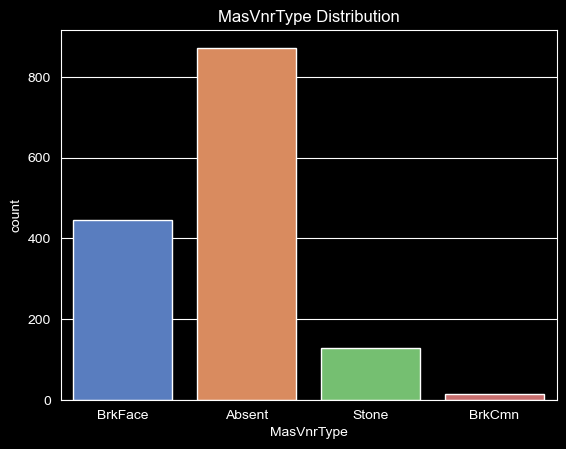

In [158]:
df['MasVnrType'] = df['MasVnrType'].fillna('Absent')

sns.countplot(data=df, x='MasVnrType', palette='muted')
plt.title('MasVnrType Distribution')
plt.show()

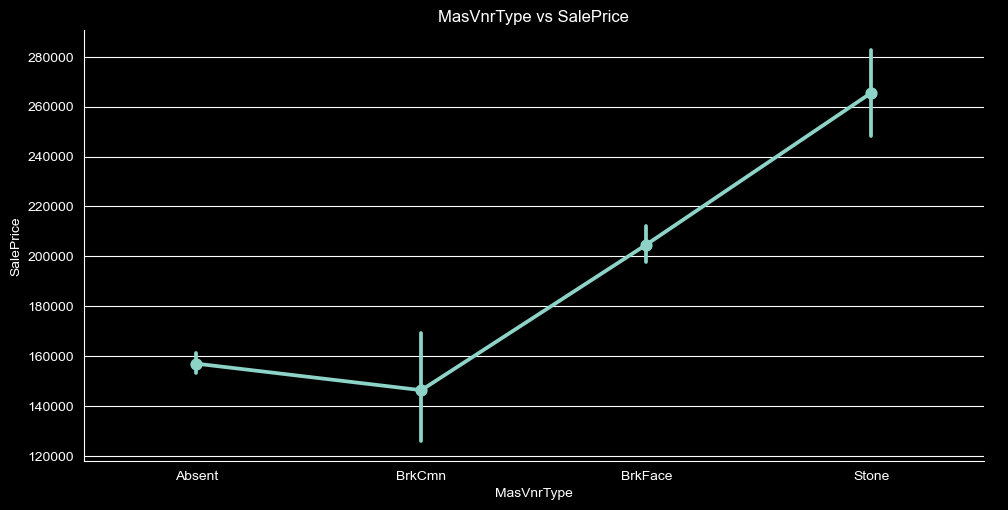

In [162]:
sns.catplot(data=df,
            x='MasVnrType',
            order=['Absent', 'BrkCmn', 'BrkFace', 'Stone'],
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('MasVnrType vs SalePrice')
plt.show()

Наблюдения:
- значение *CBlock* вообще отсутствует, возможно его стоит удалить;
- дома с черновым кирпичом стоят в среднем дешевле, чем дома вообще без облицовки; думаю, сыграла роль слишком большая разница в количестве сэмплов.

## Foundation
Тип фундамента.
- PConc — заливной монолитный железобетон;
- CBlock — фундамент из шлакоблоков;
- BrkTil — кирпич, глинянная плитка;
- Slab — плоская бетонная плитка на грунте;
- Stone — бутовый камень;
- Wood — деревянный фундамент.

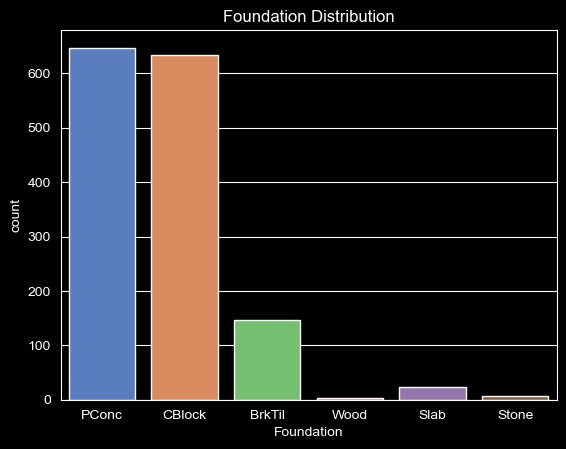

In [165]:
sns.countplot(data=df, x='Foundation', palette='muted')
plt.title('Foundation Distribution')
plt.show()

In [168]:
pd.crosstab(index=df['Foundation'],
            columns=df['Foundation'].count(),
            colnames=['Count']
).style.background_gradient(cmap='coolwarm')

Count,1460
Foundation,
BrkTil,146
CBlock,634
PConc,647
Slab,24
Stone,6
Wood,3


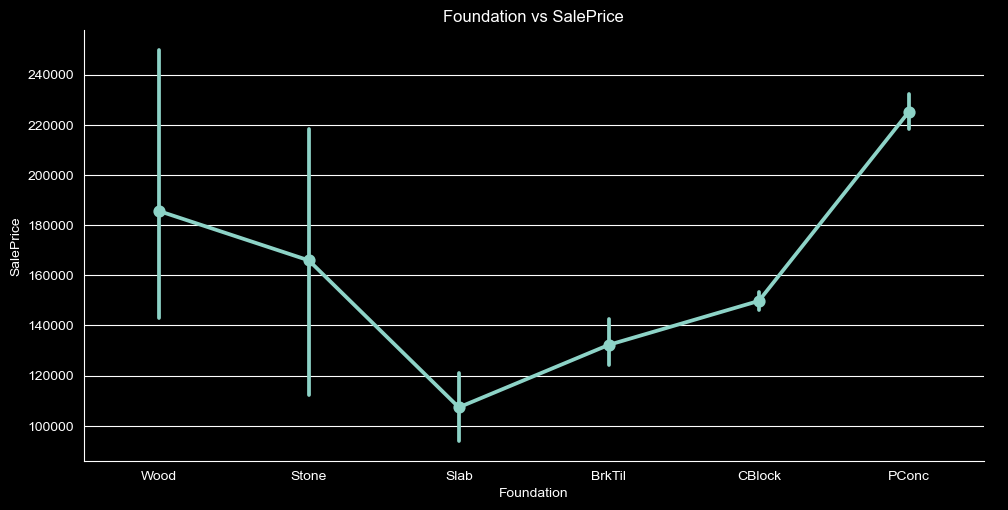

In [170]:
sns.catplot(data=df,
            x='Foundation',
            order=['Wood', 'Stone', 'Slab', 'BrkTil', 'CBlock', 'PConc'],
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('Foundation vs SalePrice')
plt.show()

Фундамент из древесины и бутовского камня является крайней экзотикой и имеет малое количество сэмплов. Сложно делать выводы по ним.\
А дальше уже идут фундаменты, расположенные в порядке повышения качестве, и видно, что с качеством фундамента растёт и стомость жилья.

## ~~Basement~~
Тут шли всякие фичи, касаемые подвала. Но у всех очевидные значения от *Good* до *Poor* / *No basement*, поэтому не стал их рассматривать, вроде там всё очевидно.\
Единственное, стоит посмотреть их итог — *TotalBsmtSF*.

## TotalBsmtSF
Общая площадь подвала в квадратных футах.

In [174]:
print(f'Min TotalBsmtSF is {df['TotalBsmtSF'].min()} \n'
      f'Max TotalBsmtSF is {df['TotalBsmtSF'].max()} \n'
      f'Mean TotalBsmtSF is {df['TotalBsmtSF'].mean()}')

Min TotalBsmtSF is 0 
Max TotalBsmtSF is 6110 
Mean TotalBsmtSF is 1057.4294520547944


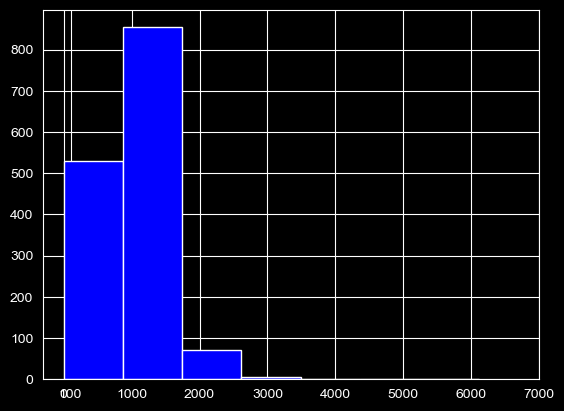

In [178]:
plt.hist(x=df['TotalBsmtSF'],
         bins=7,
         color='blue')
plt.xticks([0, 100, 1000, 2000, 3000, 4000, 5000, 6000, 7000])
plt.show()

В основном дома имеют подвал от 0 до 3 000 футов. Можно разбить на бины \[0, 1 000, 2 000, 3 000, np.inf].

In [185]:
df['TotalBsmtSF_Group'] = pd.cut(x=df['TotalBsmtSF'],
                                 bins=[0, 1000, 2000, 3000, np.inf],
                                 labels=[0, 1000, 2000, 3000],
                                 include_lowest=True)

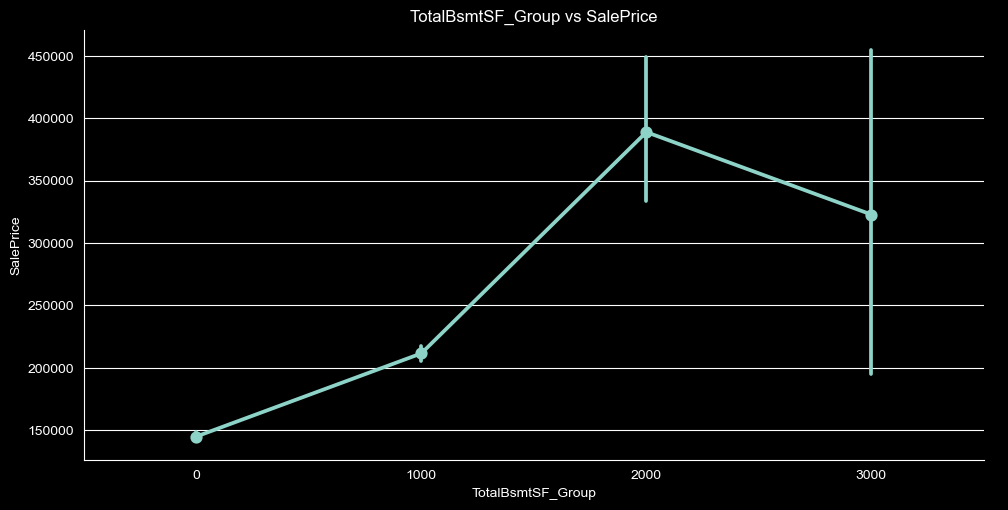

In [188]:
sns.catplot(data=df,
            x='TotalBsmtSF_Group',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('TotalBsmtSF_Group vs SalePrice')
plt.show()

## Heating
Тип отопления.

Good:
- GasA — газовая система с вентиляцией воздуха.

Fair:
- GasA — газовая система с батаерями;
- OthW — водяное отопление не на газе.

Poor:
- Floor — напольная печь в углублении дома;
- Grav — гравитационная печь;
- Wall — настенная газовая / электрическая печь.

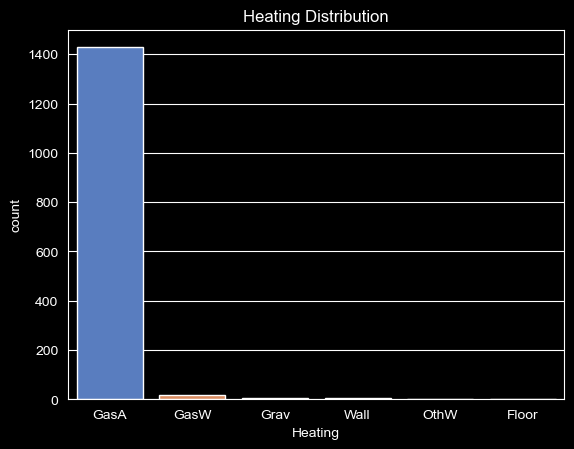

In [189]:
sns.countplot(data=df, x='Heating', palette='muted')
plt.title('Heating Distribution')
plt.show()

In [190]:
pd.crosstab(index=df['Heating'],
            columns=df['Heating'].count(),
            colnames=['Count']
).style.background_gradient(cmap='coolwarm')

Count,1460
Heating,
Floor,1
GasA,1428
GasW,18
Grav,7
OthW,2
Wall,4


In [191]:
df['Heating_Class'] = 'Absent'

good_heating = ['GasA']
fair_heating = ['GasW', 'OthW']
poor_heating = ['Floor', 'Grav', 'Wall']

df.loc[df['Heating'].isin(good_heating), 'Heating_Class'] = 'Good'
df.loc[df['Heating'].isin(fair_heating), 'Heating_Class'] = 'Fair'
df.loc[df['Heating'].isin(poor_heating), 'Heating_Class'] = 'Poor'

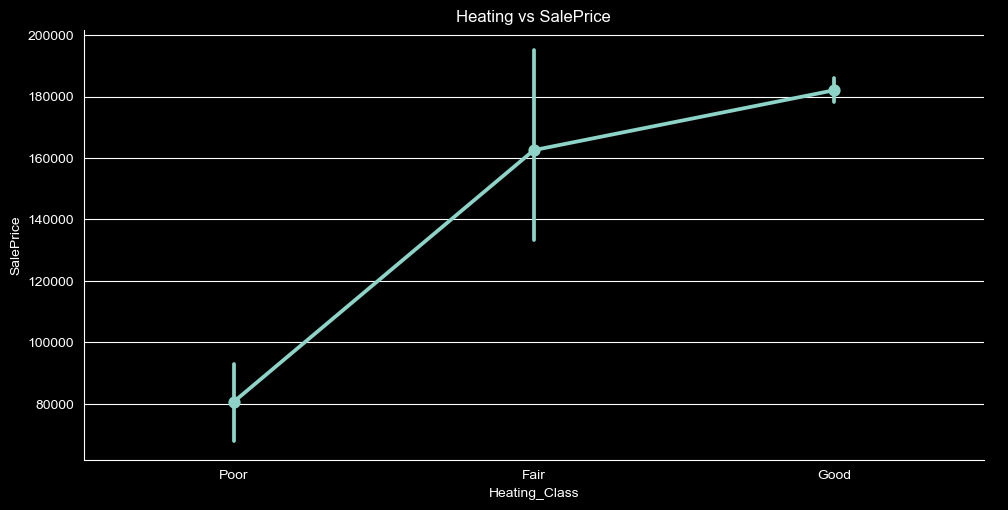

In [193]:
sns.catplot(data=df,
            x='Heating_Class',
            order = ['Poor', 'Fair', 'Good'],
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('Heating vs SalePrice')
plt.show()

## Electrical
Электическая система.

Good:
- SBrkr — современные автоматические выключатели без перегорания, медная проводка.

Fair:
- FuseA — хороший щиток, но при перегрузке перегорает пробка, хорошая проводка;
- FuseF — хороший щиток, но при перегрузке перегорает пробка, средняя проводка;

Poor:
- FuseP — старый щиток, проводка "на роликах".
- Mixed — требует ремонта.

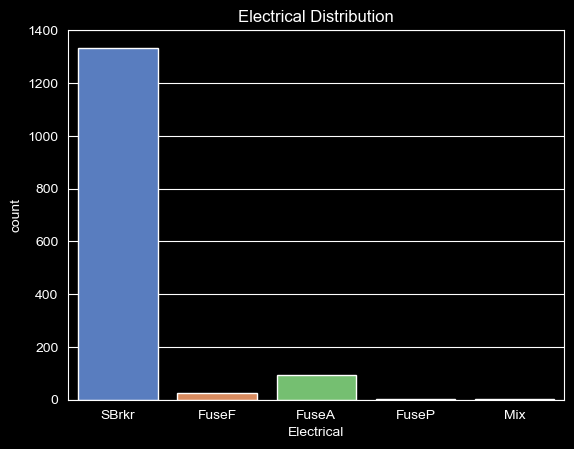

In [194]:
sns.countplot(data=df, x='Electrical', palette='muted')
plt.title('Electrical Distribution')
plt.show()

In [195]:
pd.crosstab(index=df['Electrical'],
            columns=df['Electrical'].count(),
            colnames=['Count']
).style.background_gradient(cmap='coolwarm')

Count,1459
Electrical,
FuseA,94
FuseF,27
FuseP,3
Mix,1
SBrkr,1334


In [196]:
df['Electrical_Class'] = 'Absent'

good_electrical = ['SBrkr']
fair_electrical = ['FuseA', 'FuseF']
poor_electrical = ['FuseP', 'Mixed']

df.loc[df['Electrical'].isin(good_electrical), 'Electrical_Class'] = 'Good'
df.loc[df['Electrical'].isin(fair_electrical), 'Electrical_Class'] = 'Fair'
df.loc[df['Electrical'].isin(poor_electrical), 'Electrical_Class'] = 'Poor'

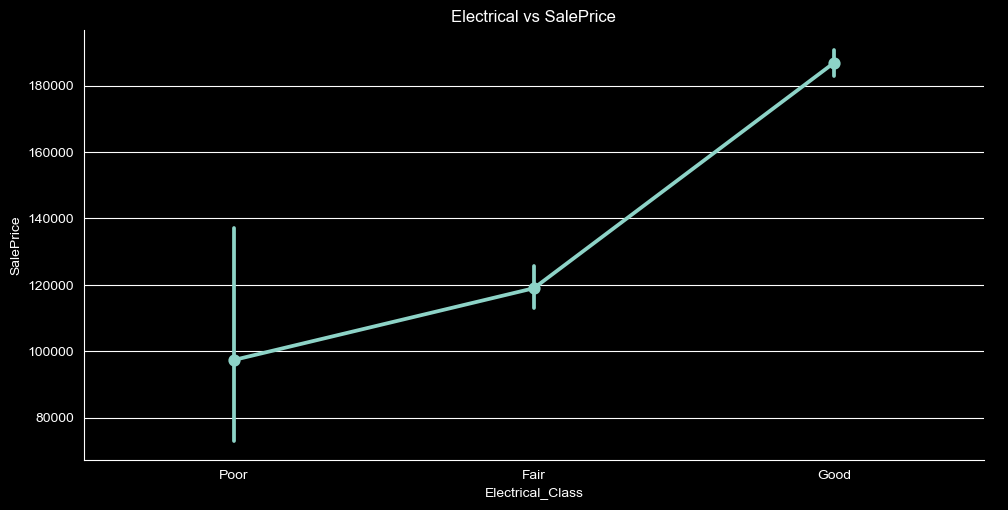

In [197]:
sns.catplot(data=df,
            x='Electrical_Class',
            order= ['Poor', 'Fair', 'Good'],
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('Electrical vs SalePrice')
plt.show()

## GrLivArea
Жилая площадь над уровнем земли.

Очень важный признак для определения стоимости дома.

In [199]:
print(f'Min GrLivArea is {df['GrLivArea'].min()} \n'
      f'Max GrLivArea is {df['GrLivArea'].max()} \n'
      f'Mean GrLivArea is {df['GrLivArea'].mean()}')

Min GrLivArea is 334 
Max GrLivArea is 5642 
Mean GrLivArea is 1515.463698630137


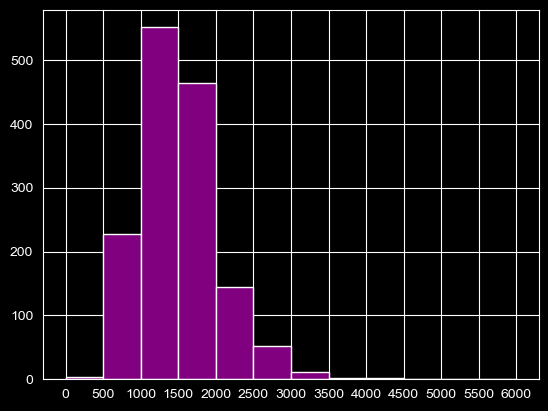

In [204]:
plt.hist(x=df['GrLivArea'],
         bins=range(0, 6001, 500),
         color='purple')
plt.xticks(range(0, 6001, 500))
plt.show()

Можно разбить на бины \[0, 500, 1000, 1500, 2000, 2500, 3000, np.inf]

In [211]:
df['GrLivArea_Group'] = pd.cut(x=df['GrLivArea'],
                               bins=[0, 500, 1000, 1500, 2000, 2500, 3000, np.inf],
                               labels=[0, 500, 1000, 1500, 2000, 2500, 3000],
                               include_lowest=True)

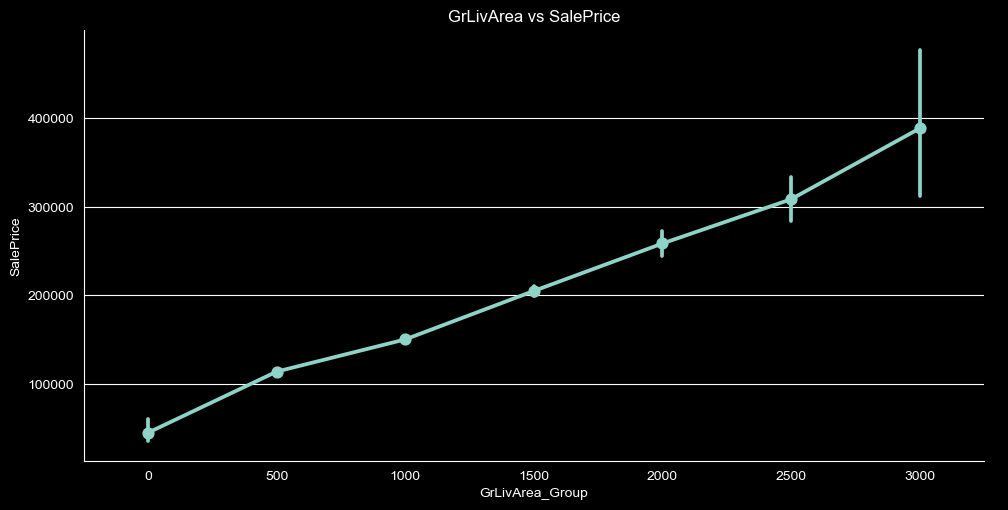

In [212]:
sns.catplot(data=df,
            x='GrLivArea_Group',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('GrLivArea vs SalePrice')
plt.show()

## FullBath
Количество ванных комната (без учёта подвала).

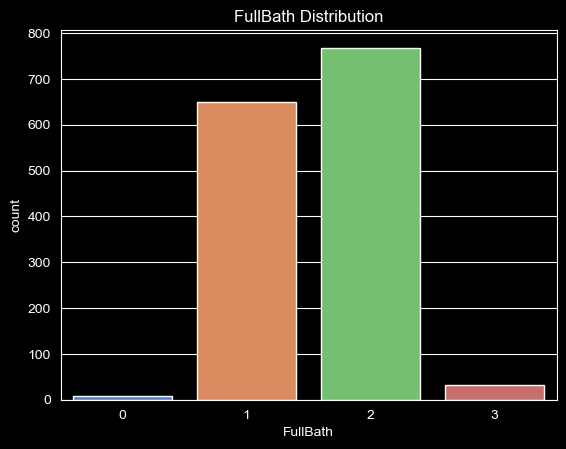

In [214]:
sns.countplot(data=df, x='FullBath', palette='muted')
plt.title('FullBath Distribution')
plt.show()

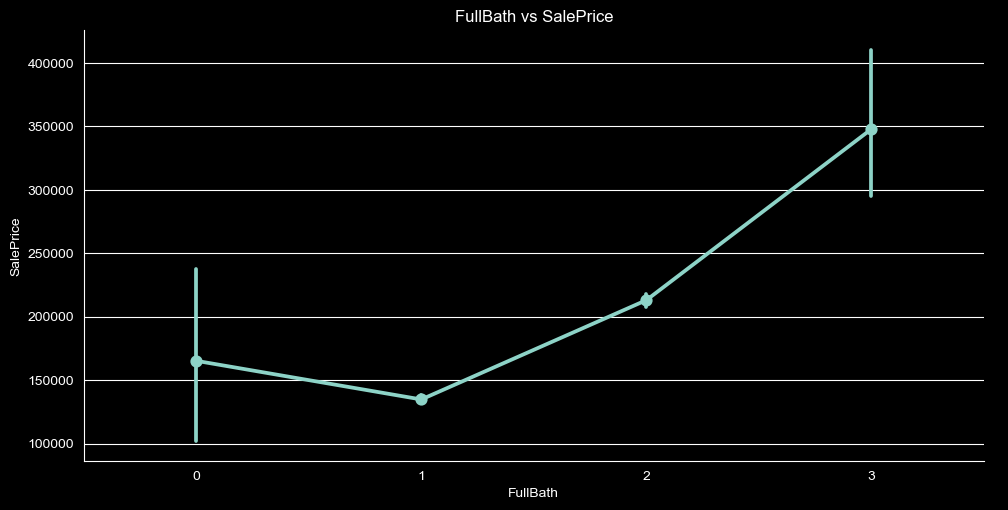

In [215]:
sns.catplot(data=df,
            x='FullBath',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('FullBath vs SalePrice')
plt.show()

## HalfBath
Количество туалетов (без подвала).

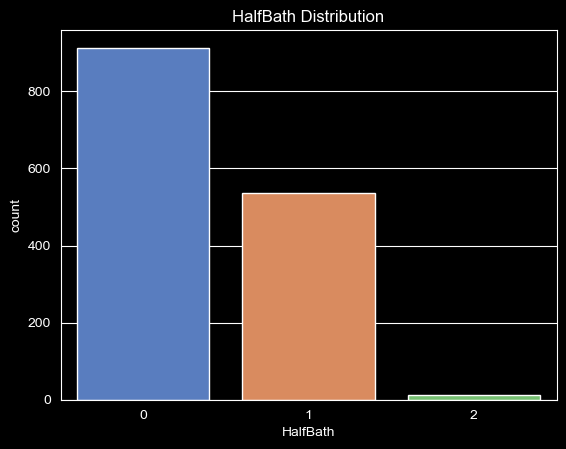

In [216]:
sns.countplot(data=df, x='HalfBath', palette='muted')
plt.title('HalfBath Distribution')
plt.show()

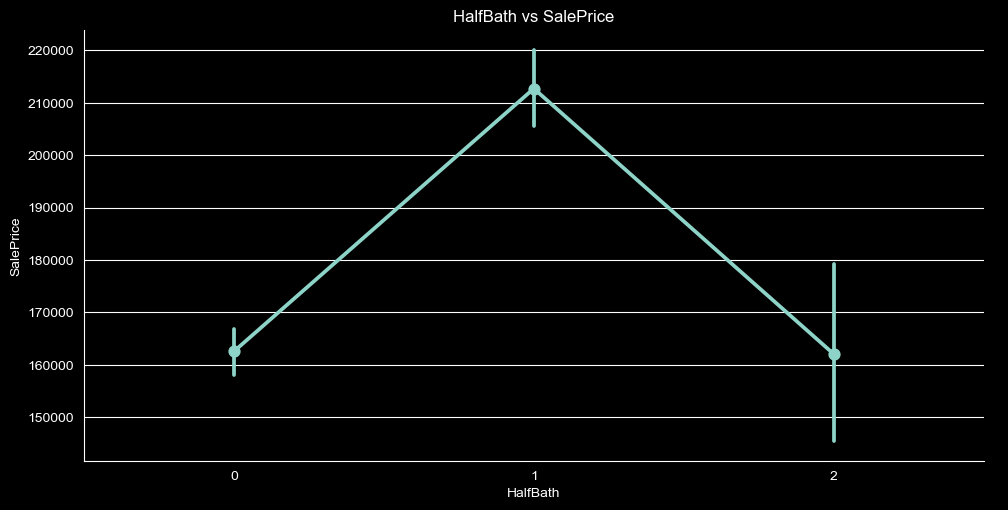

In [217]:
sns.catplot(data=df,
            x='HalfBath',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('HalfBath vs SalePrice')
plt.show()

## BedroomAbvGr
Количество спальных комнат (без учёта подвала).

Очень важный признак.

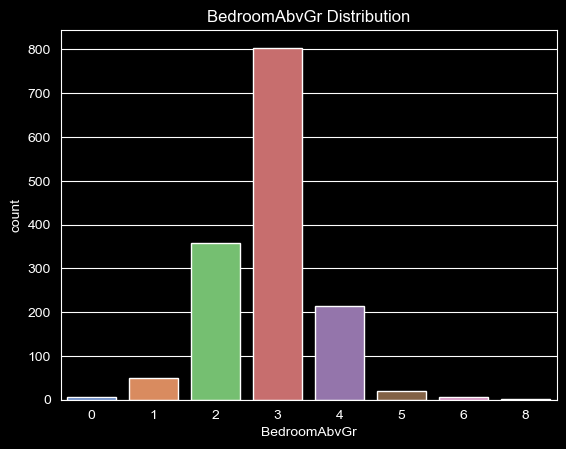

In [223]:
sns.countplot(data=df, x='BedroomAbvGr', palette='muted')
plt.title('BedroomAbvGr Distribution')
plt.show()

In [225]:
pd.crosstab(index=df['BedroomAbvGr'],
            columns=df['BedroomAbvGr'].count(),
            colnames=['Count']
).style.background_gradient(cmap='coolwarm')

Count,1460
BedroomAbvGr,
0,6
1,50
2,358
3,804
4,213
5,21
6,7
8,1


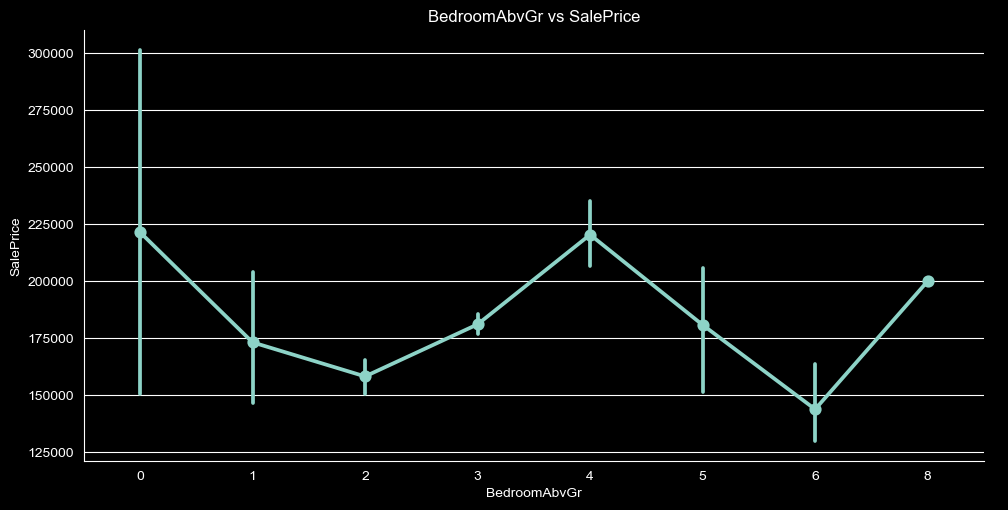

In [224]:
sns.catplot(data=df,
            x='BedroomAbvGr',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('BedroomAbvGr vs SalePrice')
plt.show()

Интересно, что дома без комнат стоят дороже, чем 1-, 2- и 3-комнатные дома. А 4-комнатные стоят дороже, чем 5-, 6- и 8-комнатные.

In [226]:
df[df['BedroomAbvGr'] == 0]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,SalePrice,LotFrontage_Group,LotArea_Group,Neighborhood_Class,Condition1_Class,Exterior1st_Class,TotalBsmtSF_Group,Heating_Class,Electrical_Class,GrLivArea_Group
53,54,20,RL,68.0,50271,Pave,Absent,IR1,Low,AllPub,...,385000,60,40,High,Normal,Wooden,1000,Good,Good,1500
189,190,120,RL,41.0,4923,Pave,Absent,Reg,Lvl,AllPub,...,286000,40,0,Highest,Normal,Premium,1000,Good,Good,1500
634,635,90,RL,64.0,6979,Pave,Absent,Reg,Lvl,AllPub,...,144000,60,5,Low,Normal,Wooden,1000,Good,Good,1000
1163,1164,90,RL,60.0,12900,Pave,Absent,Reg,Lvl,AllPub,...,108959,40,10,Low,Fair,Wooden,1000,Good,Good,1000
1213,1214,80,RL,NaN,10246,Pave,Absent,IR1,Lvl,AllPub,...,145000,NaN,10,Low,Normal,Standart,0,Good,Good,500
1270,1271,40,RL,NaN,23595,Pave,Absent,Reg,Low,AllPub,...,260000,NaN,20,High,Normal,Wooden,1000,Good,Good,1500


Домов без спальных комнат всего-лишь 6, из-за чего такой большой разброс. В таблицу выше дома в строке 1,2 и 6 имеются наибольшую стоимость, которая и повлияла на данную группу.
У данных домов большой участок земли и большой жилой участок, несмотря на отсутвие спальных комнат. Хотя дом является частным и предназначается для жилья и странно не видеть
в нём спальных комнат.

## KitchenAbvGr
Количество кухонь (не включая подвал).

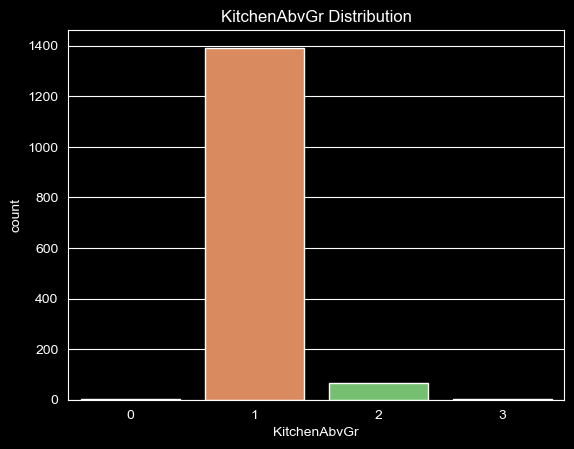

In [229]:
sns.countplot(data=df, x='KitchenAbvGr', palette='muted')
plt.title('KitchenAbvGr Distribution')
plt.show()

In [231]:
pd.crosstab(index=df['KitchenAbvGr'],
            columns=df['KitchenAbvGr'].count(),
            colnames=['Count']
).style.background_gradient(cmap='coolwarm')

Count,1460
KitchenAbvGr,
0,1
1,1392
2,65
3,2


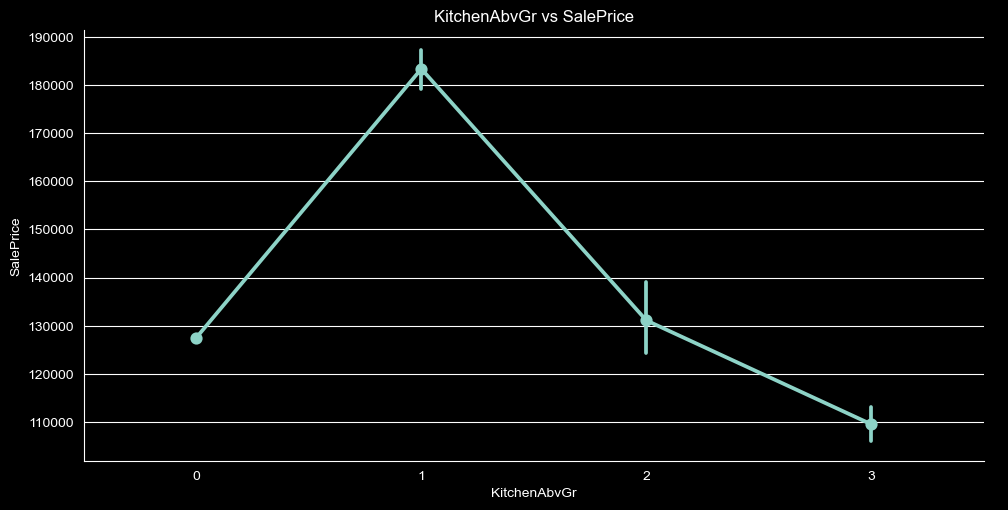

In [232]:
sns.catplot(data=df,
            x='KitchenAbvGr',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('KitchenAbvGr vs SalePrice')
plt.show()

## TotRmsAbvGrd
Общее количество комнат над уровнем земли (не включая ванные комнаты).

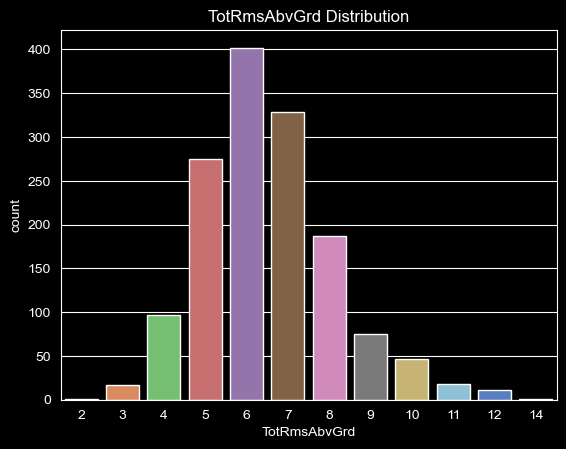

In [233]:
sns.countplot(data=df, x='TotRmsAbvGrd', palette='muted')
plt.title('TotRmsAbvGrd Distribution')
plt.show()

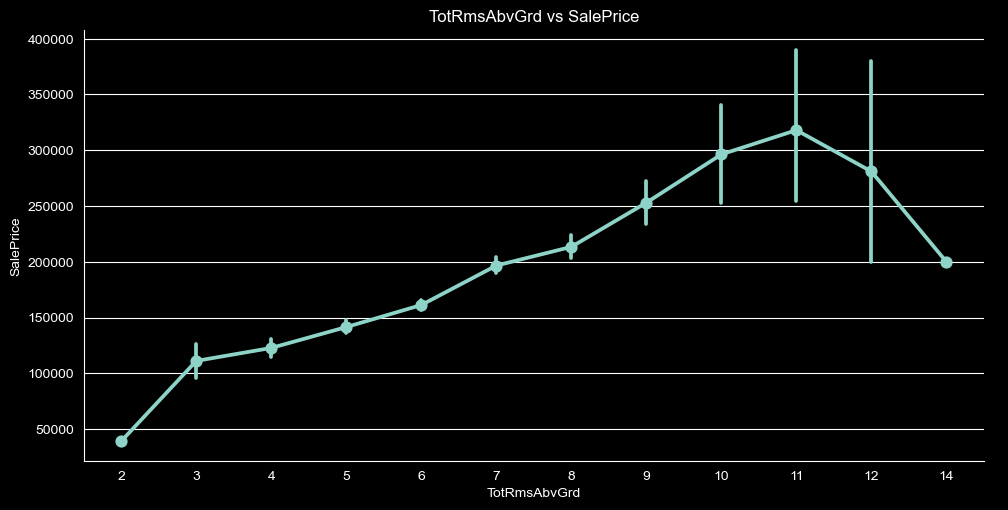

In [234]:
sns.catplot(data=df,
            x='TotRmsAbvGrd',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('TotRmsAbvGrd vs SalePrice')
plt.show()

Логично, с ростом количества комнат растёт и цена. Интересно, что после 11 комнат цена начинает падать. Хотя тут уже и достаточно мало сэмплов, чтобы делать точные выводы.

In [239]:
df[df['TotRmsAbvGrd'] == 14]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,SalePrice,LotFrontage_Group,LotArea_Group,Neighborhood_Class,Condition1_Class,Exterior1st_Class,TotalBsmtSF_Group,Heating_Class,Electrical_Class,GrLivArea_Group
635,636,190,RH,60.0,10896,Pave,Pave,Reg,Bnk,AllPub,...,200000,40,10,Low,Fair,Standart,1000,Good,Fair,3000


Видно: дома с 14 комнатами всего один + имеют нестандартную продажу, возможно изъят за долги. Отчего и снижена цена.\
Возможно стоит удалить его как шумовой объект.

In [243]:
pd.concat([df[df['TotRmsAbvGrd'] == 11].head(10), df[df['TotRmsAbvGrd'] == 12].head(10)])

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,SalePrice,LotFrontage_Group,LotArea_Group,Neighborhood_Class,Condition1_Class,Exterior1st_Class,TotalBsmtSF_Group,Heating_Class,Electrical_Class,GrLivArea_Group
11,12,60,RL,85.0,11924,Pave,Absent,IR1,Lvl,AllPub,...,345000,80,10,Highest,Normal,Wooden,1000,Good,Good,2000
118,119,60,RL,90.0,12376,Pave,Absent,Reg,Lvl,AllPub,...,320000,80,10,Medium,Normal,Wooden,1000,Good,Good,3000
324,325,80,RL,96.0,11275,Pave,Absent,Reg,Lvl,AllPub,...,242000,80,10,Medium,Good,Wooden,0,Good,Good,2500
523,524,60,RL,130.0,40094,Pave,Absent,IR1,Bnk,AllPub,...,184750,120,40,Low,Good,Premium,3000,Good,Good,3000
527,528,60,RL,67.0,14948,Pave,Absent,IR1,Lvl,AllPub,...,446261,60,10,Highest,Normal,Standart,1000,Good,Good,2500
566,567,60,RL,77.0,11198,Pave,Absent,IR1,Lvl,AllPub,...,325000,60,10,Highest,Normal,Standart,1000,Good,Good,2500
745,746,60,RL,NaN,8963,Pave,Absent,IR1,Lvl,AllPub,...,299800,NaN,5,Medium,Normal,Standart,1000,Good,Good,2500
798,799,60,RL,104.0,13518,Pave,Absent,Reg,Lvl,AllPub,...,485000,100,10,Highest,Normal,Standart,1000,Good,Good,3000
809,810,75,RM,90.0,8100,Pave,Absent,Reg,Lvl,AllPub,...,106000,80,5,Low,Normal,Outdated,0,Good,Fair,2000
875,876,60,FV,75.0,9000,Pave,Absent,Reg,Lvl,AllPub,...,303477,60,5,High,Normal,Premium,1000,Good,Good,2500


In [252]:
print(f'11 rooms: Mean LotArea is {df[df['TotRmsAbvGrd'] == 11]['LotArea'].mean()} \n'
      f'12 rooms: Mean LotArea is {df[df['TotRmsAbvGrd'] == 12]['LotArea'].mean()} \n\n'
      f'11 rooms: Mean GrLivArea is {df[df['TotRmsAbvGrd'] == 11]['GrLivArea'].mean()} \n'
      f'12 rooms: Mean GrLivArea is {df[df['TotRmsAbvGrd'] == 12]['GrLivArea'].mean()}\n\n'
      f'11 rooms: Mean YearRemodAdd is {df[df['TotRmsAbvGrd'] == 11]['YearRemodAdd'].mean()} \n'
      f'12 rooms: Mean YearRemodAdd is {df[df['TotRmsAbvGrd'] == 12]['YearRemodAdd'].mean()}')

11 rooms: Mean LotArea is 13118.277777777777 
12 rooms: Mean LotArea is 23088.0 

11 rooms: Mean GrLivArea is 2812.0 
12 rooms: Mean GrLivArea is 3097.3636363636365

11 rooms: Mean YearRemodAdd is 1995.9444444444443 
12 rooms: Mean YearRemodAdd is 1985.4545454545455


Пытаясь найти причины более низкой стоимости 12-комнытных домов, были получены сведения:
- 12-комнатные дома явлются более старые и ремонтировались намного раньше, чем 11-комнатные;
- Район расположения 12-комнатных домох в среднем хуже, чем у 11-комнатных.

Предположу, что 12-комнатные дома являются более старыми и раритетными, строились в районах, которые на тот момент ещё были хорошими. Отсюда и получается их меньшая стоимость.
Возможно 12-комнатные дома утратили свою актуальность и больше не строятся и не используются.

## Fireplaces
Количество каминов.

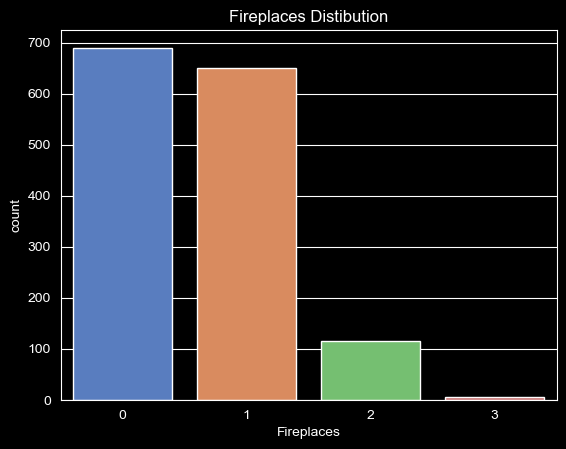

In [253]:
sns.countplot(data=df, x='Fireplaces', palette='muted')
plt.title('Fireplaces Distibution')
plt.show()

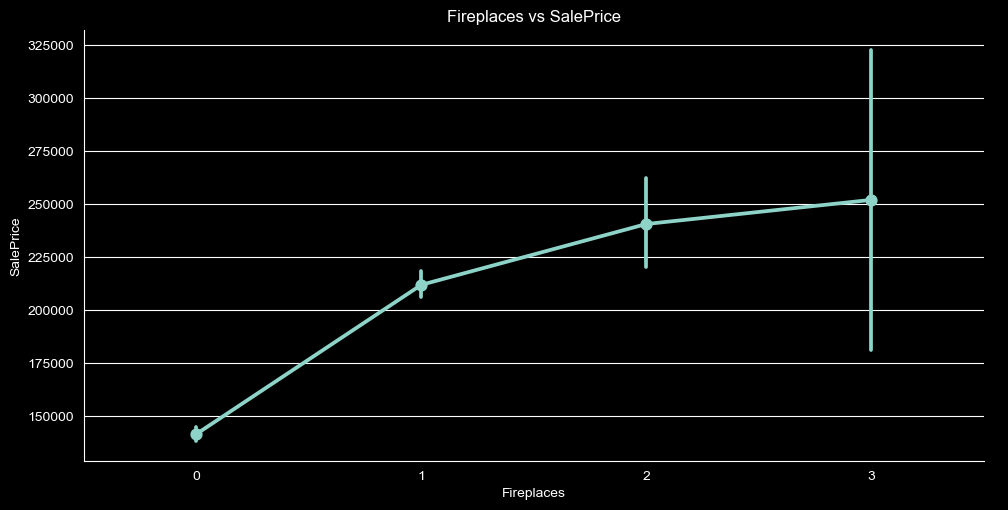

In [254]:
sns.catplot(data=df,
            x='Fireplaces',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('Fireplaces vs SalePrice')
plt.show()

Не ожидал, что будут явная корреляция между количеством каминов и стоимостью жилья. Понятно, что она должна быть, но до этого такими второстепенные характеристики
показывали очень неожиданный результат. Если проанализировать данные, можно увидеть, что несколько каминов стоит в домах с большим количеством комнат. Логично:
обычно камины ставятся в центральных комната по типу зала, холла и т.п., поэтому большое количество каминов говорит и наличие нескольких масштабных комнат в доме и
большой площади.

## GarageType
Расположение гаража.
- 2Types — наличие 2-х гаражей;
- Attchd — прикреплённый к дому;
- Basment — гараж в подвале;
- BuiltIn — встроен в дом (обычно над ним есть жилая комната);
- CarPort — навес для машины (без капитальных стен);
- Detchd — отдельное здание гаража во дворе;
- NA — гараж отсутствует.

In [261]:
df['GarageType'] = df['GarageType'].fillna('Absent')

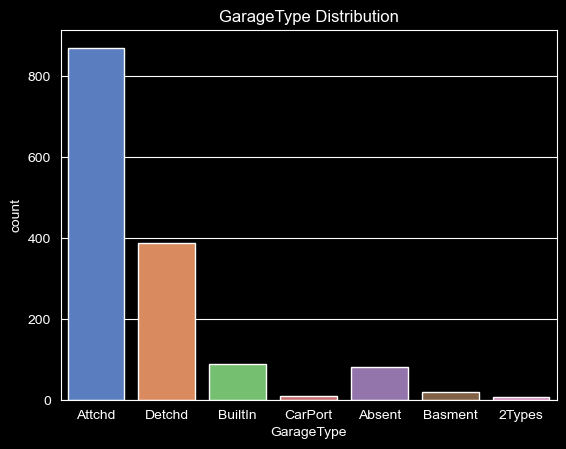

In [262]:
sns.countplot(data=df, x='GarageType', palette='muted')
plt.title('GarageType Distribution')
plt.show()

In [263]:
pd.crosstab(index=df['GarageType'],
            columns=df['GarageType'].count(),
            colnames=['Count']
).style.background_gradient(cmap='coolwarm')

Count,1460
GarageType,
2Types,6
Absent,81
Attchd,870
Basment,19
BuiltIn,88
CarPort,9
Detchd,387


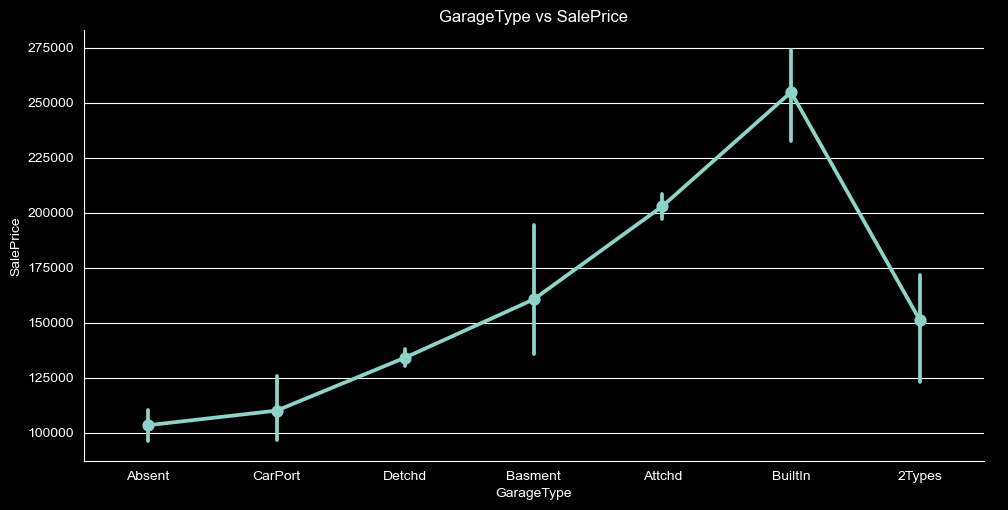

In [266]:
sns.catplot(data=df,
            x='GarageType',
            order=['Absent', 'CarPort', 'Detchd', 'Basment', 'Attchd', 'BuiltIn', '2Types'],
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('GarageType vs SalePrice')
plt.show()

Логичная корреляция между типом гаража и тагретом. Резкое падение на 2-типовом гараже. Возможно там плохие типы гаражей, которые в сумме являются хуже,
чем прикреплённый или встроенный гараж.

## GarageFinish
Внутренняя отделка гаража.
- Fin — гараж с полноценным ремонтом.
- RFn — гараж готов к использование, но отсутствует какой-либо косметический ремонт;
- Unf — недостроен;
- NA — гараж отсутствует.

In [268]:
df['GarageFinish'] = df['GarageFinish'].fillna('Absent')

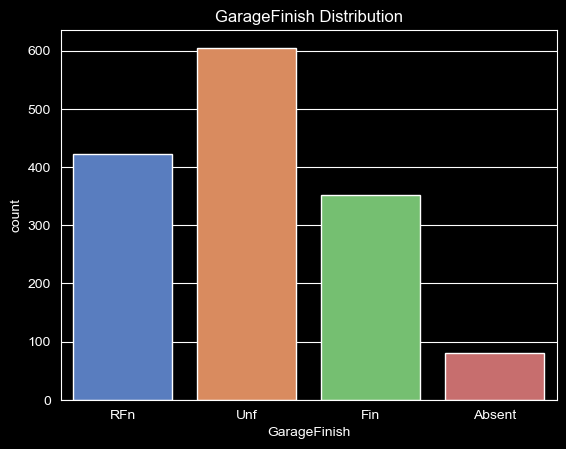

In [269]:
sns.countplot(data=df, x='GarageFinish', palette='muted')
plt.title('GarageFinish Distribution')
plt.show()

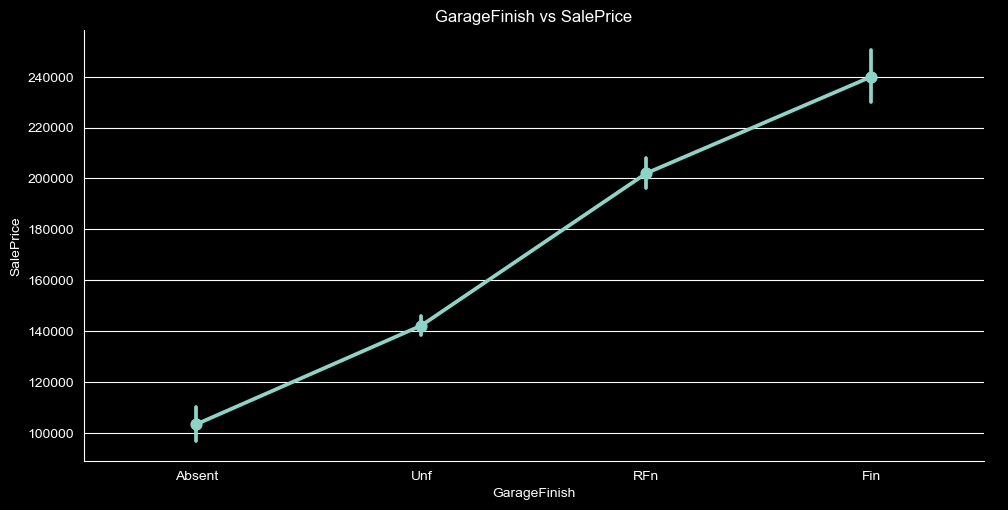

In [271]:
sns.catplot(data=df,
            x='GarageFinish',
            order=['Absent', 'Unf', 'RFn', 'Fin'],
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('GarageFinish vs SalePrice')
plt.show()

## PavedDrive
Материал дорожки, ведущая от улицы к гаражу или парковке.
- Y — твёрдое покрытие (асфальт, бетон);
- P — рассыпное покрытие (щебень, гравий);
- N — грутновое покрытие (обычная земля).

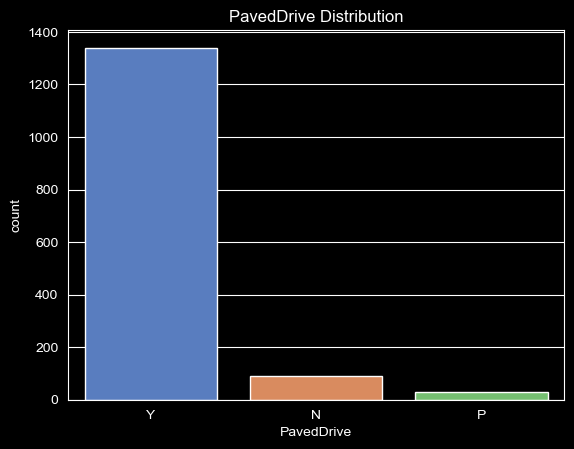

In [275]:
sns.countplot(data=df, x='PavedDrive', palette='muted')
plt.title('PavedDrive Distribution')
plt.show()

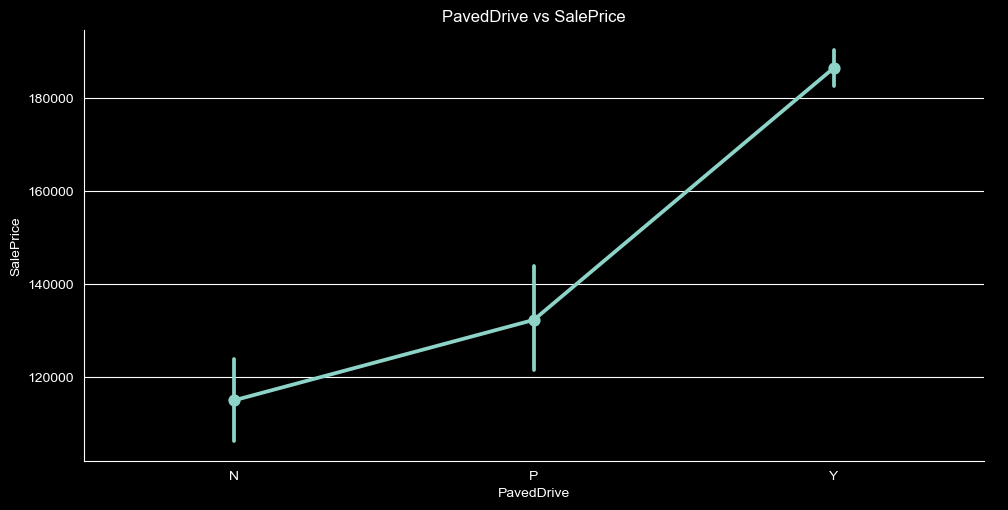

In [277]:
sns.catplot(data=df,
            x='PavedDrive',
            order=['N', 'P', 'Y'],
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('PavedDrive vs SalePrice')
plt.show()

## OpenPorchSF & EnclosedPorch
Обе фичи говорят о наличии открытой и закрытой веранды у дома. Анализировать не буду, понятно, чем больше веранда, тем лучше.\

Одна интересен факт, что в некоторых домах есть и открытая, и закрытая веранда. Не думал, что такое вооще возможно, но интернет считает это хорошим решением.
Так что обе эти фичи можно скомбинировать при фича-инженеринге для лучшего результата.

Ну и дальше ещё идут фичи, показывающие площадь 3-сезонной веранды, который можно пользоваться все сезоны, кроме зимы, и площадь веранды с москитной сеткой.
Тоже можно будет попробовать скомбинировать все эти 4 признака.

## Fence
Показывает качество забора.\
- GdPrv — хорошая конфиденциальность;
- MnPrv — минимальная конфиденциальность;
- GdWo — хороший забор (без приватности);
- MnWw — минимальный забор;
- NA — забор отсутствует.

In [282]:
df['Fence'] = df['Fence'].fillna('Absent')

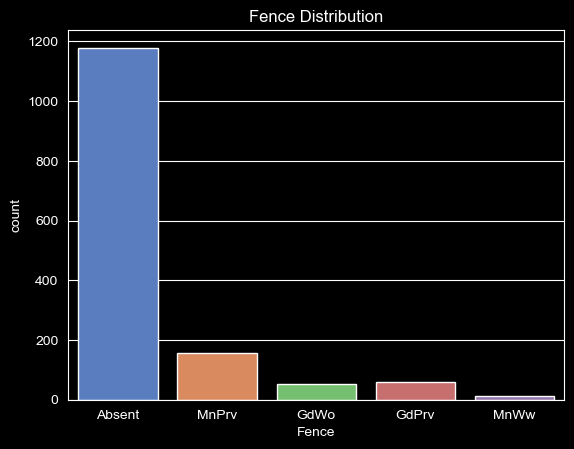

In [291]:
sns.countplot(data=df, x='Fence', palette='muted')
plt.title('Fence Distribution')
plt.show()

In [292]:
pd.crosstab(index=df['Fence'],
            columns=df['Fence'].count(),
            colnames=['Count']
).style.background_gradient(cmap='coolwarm')

Count,1460
Fence,
Absent,1179
GdPrv,59
GdWo,54
MnPrv,157
MnWw,11


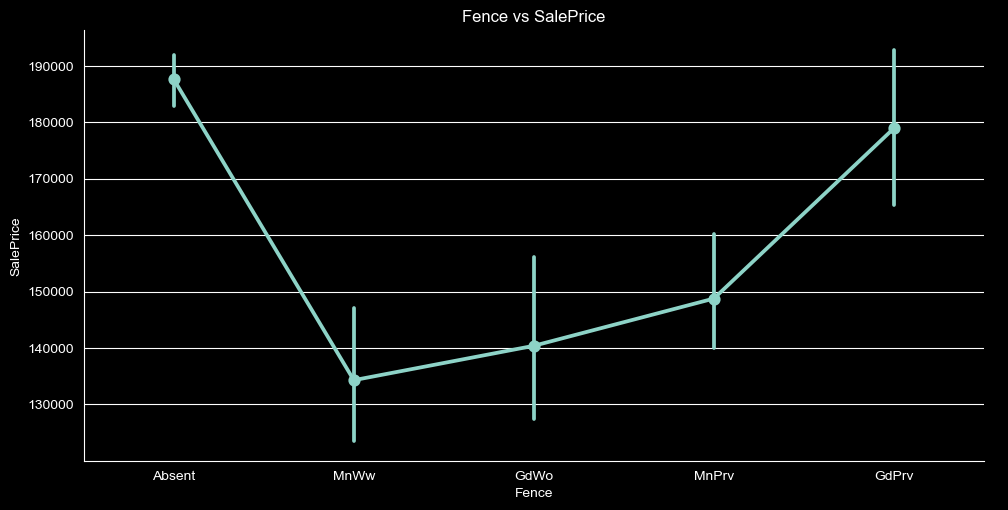

In [294]:
sns.catplot(data=df,
            x='Fence',
            order=['Absent', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv'],
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('Fence vs SalePrice')
plt.show()

В принципе, корреляция забора и таргета видна. Выбивает из данного графика только дома без забора. Но это объяснить можно: количество домов без забора во много-много раз
превышают количество остальных домов. Всех остальных домов немного в каждом классе и поэтом они показывают естественный рост.

## MiscFeature
Дополнительные объекты, не рассмотренные в других категориях.
- Elev — лифт;
- Gar2 — 2-ой гараж (если нет описания в категории гаража);
- Othr — другое;
- Shed — сарай (более 100 футов);
- TenC — теннисный корт4
- NA — ничего.

Интересная фича, т.к. изначально не совсем понятно что ценнее и в каком порядке это расположить.

In [297]:
df['MiscFeature'] = df['MiscFeature'].fillna('Absent')

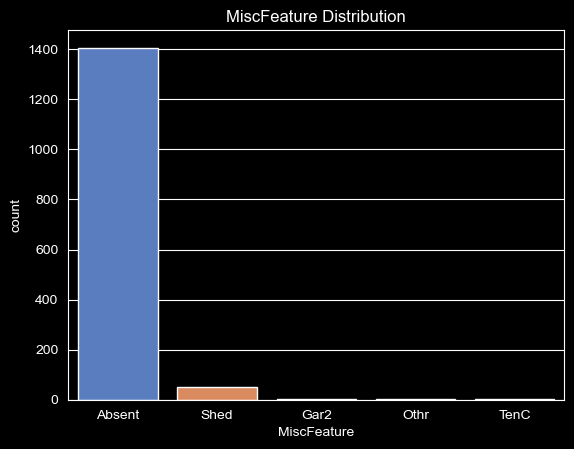

In [299]:
sns.countplot(data=df, x='MiscFeature', palette='muted')
plt.title('MiscFeature Distribution')
plt.show()

In [301]:
pd.crosstab(index=df['MiscFeature'],
            columns=df['MiscFeature'].count(),
            colnames=['Count']
).style.background_gradient(cmap='coolwarm')

Count,1460
MiscFeature,
Absent,1406
Gar2,2
Othr,2
Shed,49
TenC,1


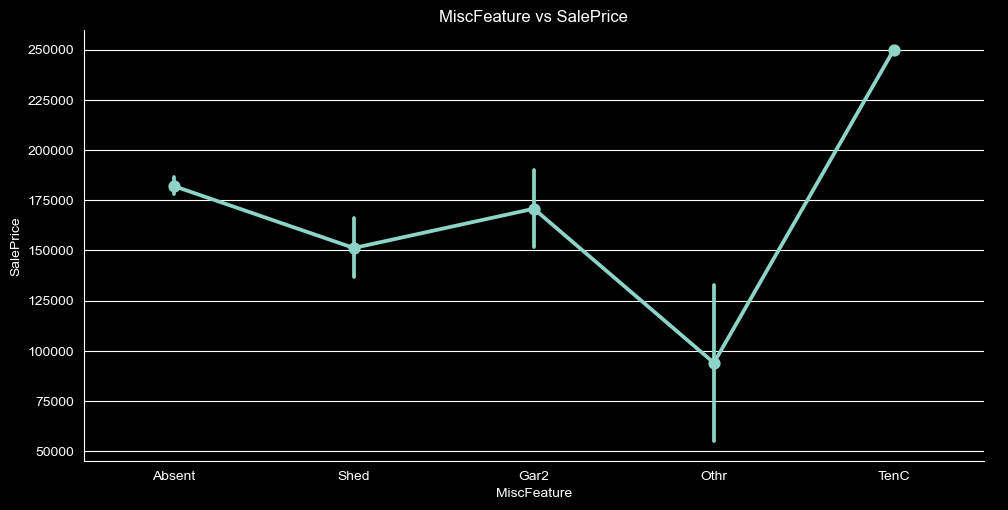

In [302]:
sns.catplot(data=df,
            x='MiscFeature',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('MiscFeature vs SalePrice')
plt.show()

In [303]:
df[df['MiscFeature'] == 'TenC']

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,SalePrice,LotFrontage_Group,LotArea_Group,Neighborhood_Class,Condition1_Class,Exterior1st_Class,TotalBsmtSF_Group,Heating_Class,Electrical_Class,GrLivArea_Group
1386,1387,60,RL,80.0,16692,Pave,Absent,IR1,Lvl,AllPub,...,250000,60,15,Medium,Poor,Wooden,1000,Good,Good,2500


Не ожидал, что дом с теннисоным кортом будет стоить дороже всех. Но если изучить данные данного дома, видно, что дом обустроен хорошо: там есть и бассейн, и большая веранда,
несколько каминов, несколько этажей, большую площадь и в сумме 12 комнат (напомю, в датасете всего-лишь 11 домов с 12 комнатами).\
Так что этот дом в принципе очень дорогой. И можно предположить, что теннисный корт строят в домах, в которых итак уже всё есть, просто пытаются застроить свободную
площадь чем-то полезным.

In [305]:
df[df['MiscFeature'] == 'Othr']

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,SalePrice,LotFrontage_Group,LotArea_Group,Neighborhood_Class,Condition1_Class,Exterior1st_Class,TotalBsmtSF_Group,Heating_Class,Electrical_Class,GrLivArea_Group
705,706,190,RM,70.0,5600,Pave,Absent,Reg,Lvl,AllPub,...,55000,60,5,Lowest,Normal,Standart,0,Good,Good,1000
873,874,40,RL,60.0,12144,Pave,Absent,Reg,Lvl,AllPub,...,133000,40,10,Medium,Normal,Standart,0,Good,Good,1000


Интересно, что дома со значением *Othr* стоят меньше всего. И максимально непонятно что входит в это "Другое". Причём у одного дома это значение есть, а ценность всё равно 0.
Как будто стоит преобразовать его значение *Othr* в *Absent*, чтобы модель не учила нулевую стоимость.

Ну и в принципе видно, что дополнительные какие-то объекты в доме не представляют ценности. И даже получается, что наличие таких объектов говорит о плохом качестве дома и его
низкой стоимости (кроме домов с теннисным кортом).

## MoSold
Месяц продажи

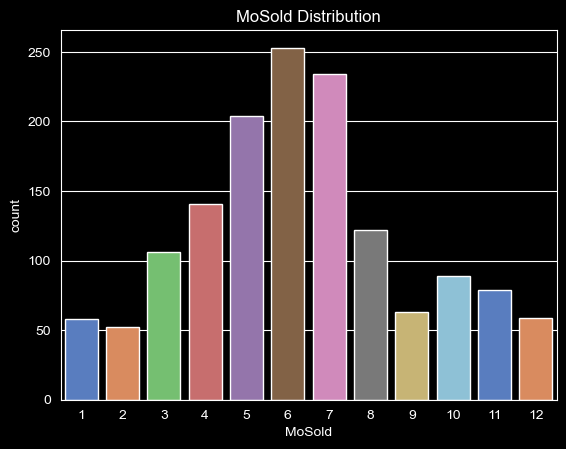

In [309]:
sns.countplot(data=df, x='MoSold', palette='muted')
plt.title('MoSold Distribution')
plt.show()

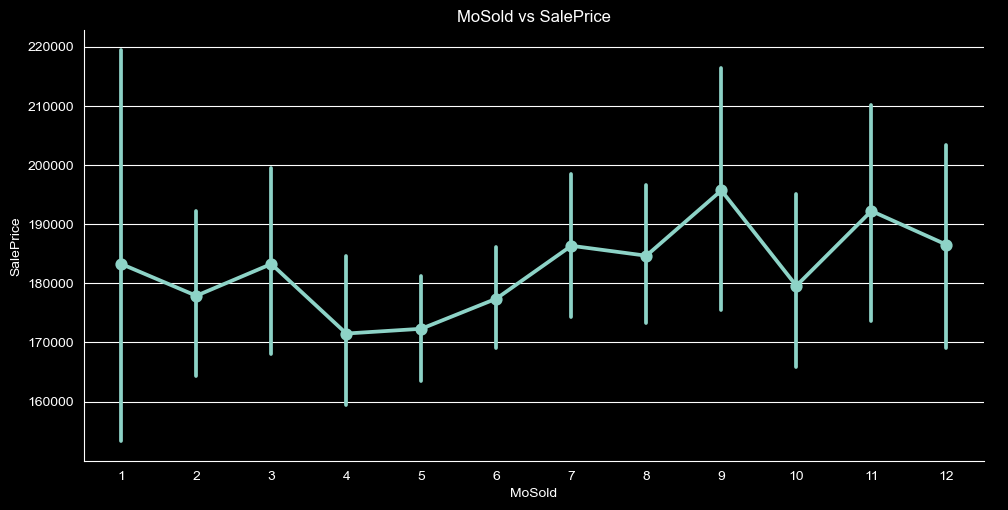

In [310]:
sns.catplot(data=df,
            x='MoSold',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('MoSold vs SalePrice')
plt.show()

Тупой анализ какой-то получился. Вряд-ли стоимость такой важной вещи как дом будет зависить от месяца продажи...

## YrSold
Год продажи

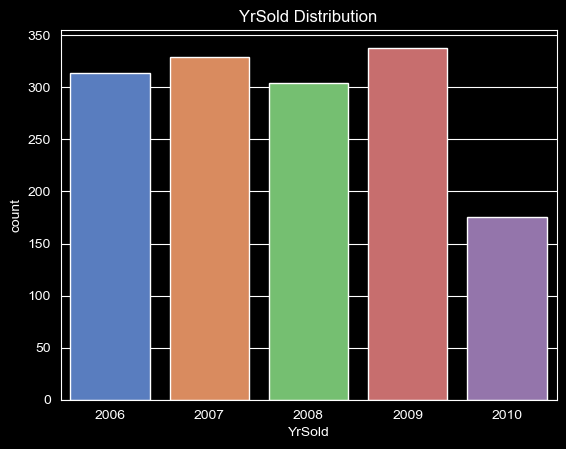

In [314]:
sns.countplot(data=df, x='YrSold', palette='muted')
plt.title('YrSold Distribution')
plt.show()

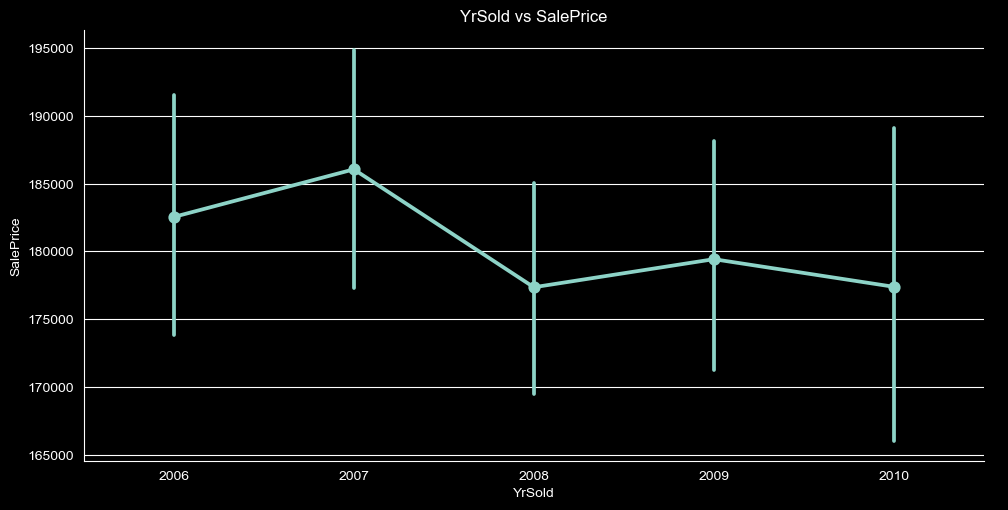

In [316]:
sns.catplot(data=df,
            x='YrSold',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('YrSold vs SalePrice')
plt.show()

Видно рост цен на дома до 2008 года, и в 2008 резкое падение. Видимо, это тот самый ипотечный кризис, о котором я упоминал в начале анализа.

В 2009 году снова подъём цен, а в 2010 снова спад. Всё это время продолжались последствия ипотечного кризиса 2008 года. А в 2010 году как рза был пик изъятия жилья банками
за неуплату долгов.

# SaleType
Тип продажи.
- WD — стандартная гарантийная покупка;
- CWD — гарантийная покупка с быстрой оплатой наличными;
- VWD — гарантийная покупка по военной льготной ипотеке;
- New — новый дом, только что построенный и проданный застройщиком;
- COD — продажа после изъятия имущества (за долги);
- Con — прямая рассрочка от продавца (взнос 15%);
- ConLw — рассрочка с низким взносом и низкой ставкой;
- ConLI — рассрочка с пониженной процентной ставкой;
- ConLD — рассрочка с низним первоначальным взносом;
- Oth — другие нестандартные типы договоров.

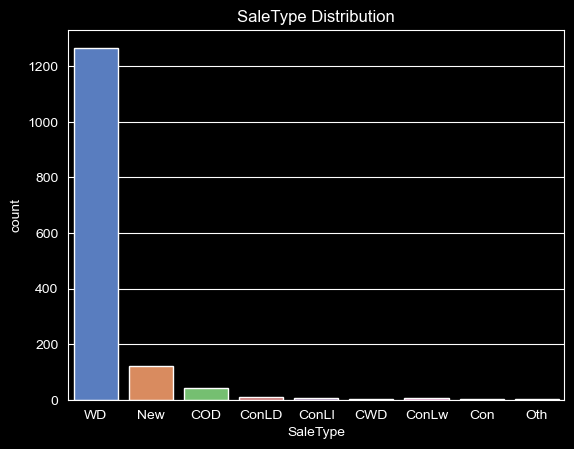

In [319]:
sns.countplot(data=df, x='SaleType', palette='muted')
plt.title('SaleType Distribution')
plt.show()

In [320]:
pd.crosstab(index=df['SaleType'],
            columns=df['SaleType'].count(),
            colnames=['Count']
).style.background_gradient(cmap='coolwarm')

Count,1460
SaleType,
COD,43
CWD,4
Con,2
ConLD,9
ConLI,5
ConLw,5
New,122
Oth,3
WD,1267


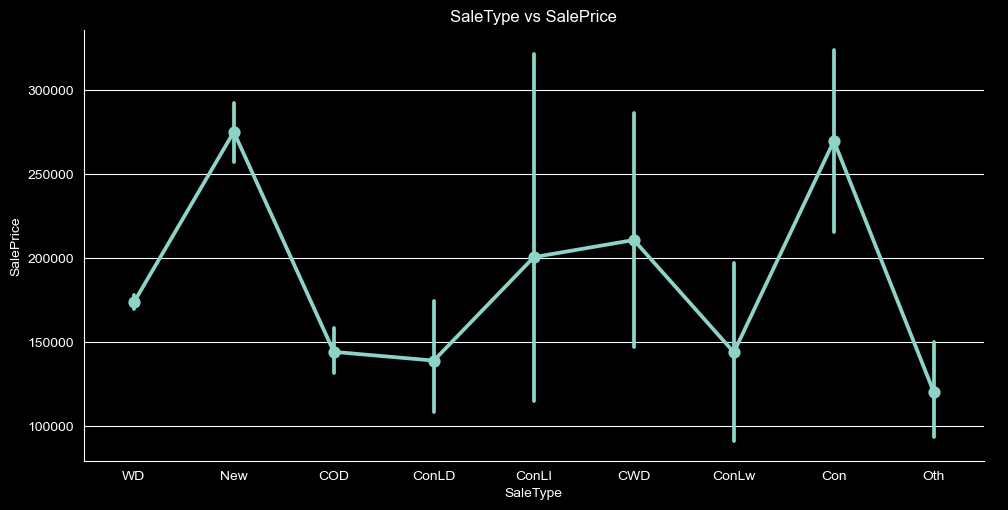

In [321]:
sns.catplot(data=df,
            x='SaleType',
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('SaleType vs SalePrice')
plt.show()

## SaleCondition
Условия продажи.
- Normal — нормальная, спокойная сделка;
- Abnorml — очень срочная продажа;
- AdjLand — покупка прилегающегося земельного участка;
- Alloca — сделка с выделением долей (напр, продажа двух смежных участков);
- Family — семейная сделка (скидка по-братски);
- Partial — частичная выплата (свяазана с покупкой навостройки).

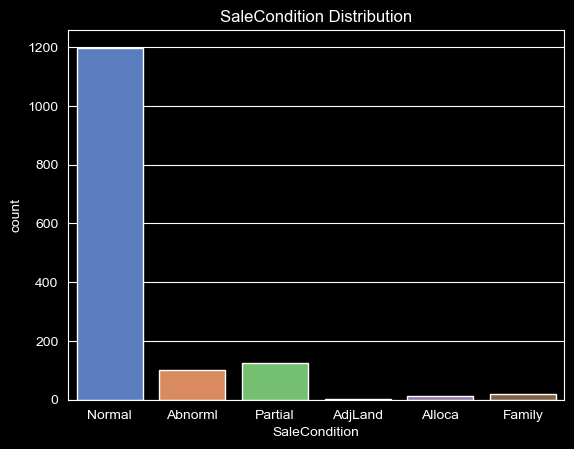

In [322]:
sns.countplot(data=df, x='SaleCondition', palette='muted')
plt.title('SaleCondition Distribution')
plt.show()

In [323]:
pd.crosstab(index=df['SaleCondition'],
            columns=df['SaleCondition'].count(),
            colnames=['Count']
).style.background_gradient(cmap='coolwarm')

Count,1460
SaleCondition,
Abnorml,101
AdjLand,4
Alloca,12
Family,20
Normal,1198
Partial,125


# Корреляция между признаками


In [318]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

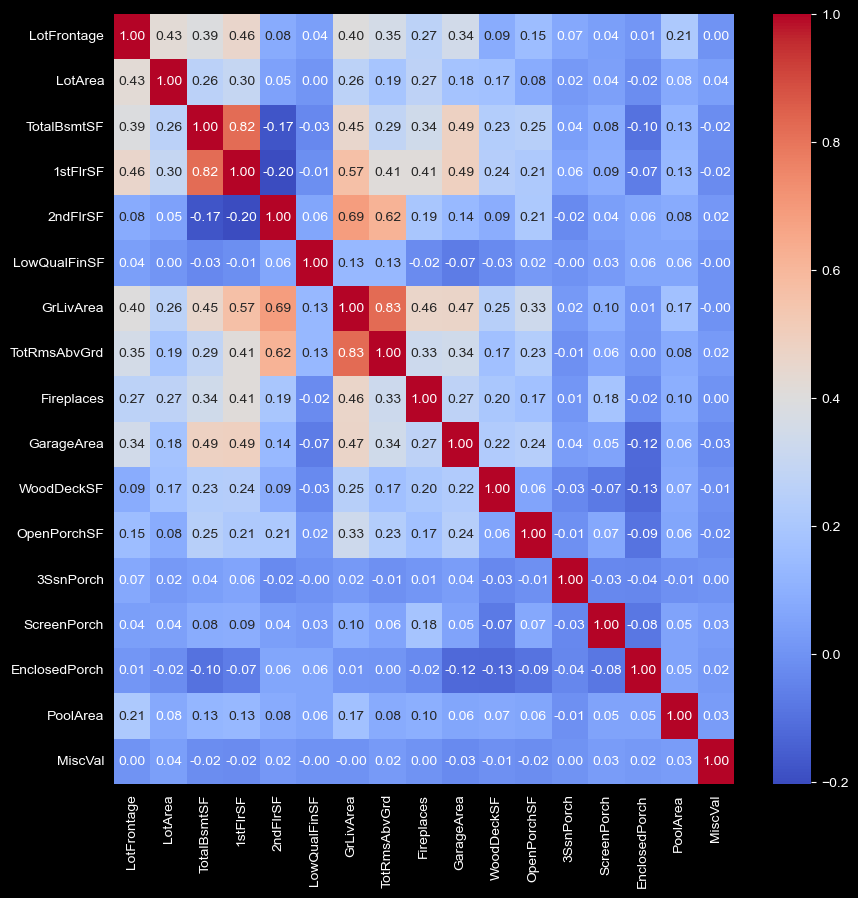

In [346]:
features = ['LotFrontage', 'LotArea', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'TotRmsAbvGrd', 'Fireplaces', 'GarageArea', 'WoodDeckSF',
            'OpenPorchSF', '3SsnPorch', 'ScreenPorch', 'EnclosedPorch', 'PoolArea', 'MiscVal']

plt.figure(figsize = (10,10))
sns.heatmap(data=df[features].corr(),
            annot=True,
            cmap='coolwarm',
            linewidths=0,
            fmt='.2f')
plt.show()

Тут не все фичи, но рассмотрел самые важные. Видна некоторая сильная корреляция между признаками, но эти признаки типо "Площадь 1-го этажа", "Площадь 2-го этажа",
"Общая площадь этажа" и "Площадь недостроенного помещения". Очевидно они будут коррелировать. Такая же ситуация и с площадью подвалов.\
Т.к. нам важно максимизировать качество предитка, оставим все фичи.